# B± → π±π±π∓ — QMI em bins com x, y, dx, dy

Cópia do notebook 26. Cada um dos 25 bins constantes tem quatro parâmetros
compartilhados entre cargas, `S_QMI.bin_NN.x/y/dx/dy`:
`QMI_plus = (x+dx) + i(y+dy)` e `QMI_minus = (x-dx) + i(y-dy)`.
São parâmetros de dinâmica, pois alteram a forma da onda-S.

O coeficiente CPV global `S_QMI.x/y/dx/dy` continua livre e multiplica essas
formas. No primeiro bin, `x=1, y=dx=dy=0` ficam fixos. No bin do veto D0,
os quatro valores ficam fixos em zero. Os demais bins têm os quatro livres.
Mantemos 117 parâmetros livres, nenhuma normalização individual e nenhuma
interpolação ou penalidade de suavidade. A transformação das sementes preserva
as amplitudes iniciais do notebook 26 em ambas as cargas.

Os gráficos e comparações resolvem x±dx e y±dy antes de multiplicar pelo
coeficiente global. O helper local `CPBinPart` usa a resolução de parâmetros
da API; exportar esse modelo em JSON exige registrar esse helper como plugin.


In [41]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jax

from dalitzplotfitter import (
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DecayChannel,
    DecayModel,
    GounarisSakurai,
    MassWindowVeto,
    Parameter,
    PhaseSpaceSample,
    QMI,
    RealImag,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    RelativisticBreitWigner,
    Resonance,
    SigmaPole,
    ZemachP,
    enable_x64,
    delta_method_errors,
    read_root_histogram2d,
    read_root_tree,
    kdtree_local_residuals,
)

enable_x64()
#jax.config.update("jax_captured_constants_report_frames", 10)

## Configuração e proveniência dos inputs

Dados, mapas, yields e assimetrias iniciais são preservados conforme solicitado pelo usuário,
a partir de `GenFit3piCP_R2_415489.cc`. A diferença de yields para a Tabela 3 do draft
é uma limitação explícita da reprodução, não uma alteração a aplicar ao ROOT atual.


In [42]:
INPUTS = Path("/Users/juanleite/Work/data/fit415489_pipipinotav3_21-5--11h32m13s415489/inputs")

DATA_FILE = INPUTS / "data15161718_pipipi_LauNoSpike.root"
DATA_TREE = "fitTree"

ACC_FILE = INPUTS / "ACC_pipipi_15161718_NoSpike_prodAsy.root"
ACC_HIST_PLUS = "Hacc_pipipi_15161718_Plus"
ACC_HIST_MINUS = "Hacc_pipipi_15161718_Minus"

QQBAR_BKG_FILE = INPUTS / "Lau_3pi_BKG_pm_322_V2h_splot_normcut.root"
QQBAR_HIST_PLUS = "hbkgbp"
QQBAR_HIST_MINUS = "hbkgbm"

KPIPI_BKG_FILE = INPUTS / "bkg_kpipi_histo.root"
KPIPI_HIST = "hbkg"  # same histogram used for both B+ and B- in the .cc

D0_VETO_MIN_GEV = 1.74
D0_VETO_MAX_GEV = 1.894

N_TOTAL_EVENTS = 95110.0
SIGNAL_FRACTION = 0.8845
QQBAR_FRACTION = 0.1155
N_SIGNAL = N_TOTAL_EVENTS * SIGNAL_FRACTION
N_QQBAR = N_TOTAL_EVENTS * QQBAR_FRACTION
QQBAR_YIELD_ASYMMETRY = -0.0078  # qqbarEventsAsym, fixed

N_KPIPIBKG = 0. # nBgkpipiEvents = 95120*.0, fixed -- inert, kept only for structural fidelity
KPIPIBKG_YIELD_ASYMMETRY = 0.03  # kpipibkgEventsAsym, fixed -- inert since the yield above is 0

N_STARTS=1

print(f"N_signal = {N_SIGNAL:.3f}   N_qqbar = {N_QQBAR:.3f}   sum = {N_SIGNAL + N_QQBAR:.3f}")

NORMALIZATION_CONFIG = {
    "normalization_method": "square-dalitz",
    #"normalization_method": "gauss-legendre",
    "normalization_pair": (0,1),
    #"normalization_binning_factor": 30,
    "normalization_chunk_size": 100_000,
    "dynamics_microbatch_size": 100_000,
    #"normalization_resolution": 500
}

N_signal = 84124.795   N_qqbar = 10985.205   sum = 95110.000


## Canais e veto

`DecayChannel` resolve massa do pai e das filhas via o pacote `particle`; usamos essas mesmas
massas para as coordenadas Square-Dalitz do ACC/background abaixo, garantindo consistência interna
com o que `DecayModel` usa.

In [43]:
PLUS_CHANNEL = DecayChannel("B+", ("pi+", "pi+", "pi-"))
MINUS_CHANNEL = DecayChannel("B-", ("pi-", "pi-", "pi+"))

MOTHER_MASS = PLUS_CHANNEL.parent_mass
DAUGHTER_MASSES = PLUS_CHANNEL.daughter_masses
SQDP_PAIR = (0, 1)  # the two identical pi+/pi-, per the sibling Laura-toy benchmark notebook
RESONANCE_PAIR = (2, 0)  # resPairAmpInt=2 for every resonance in the .cc

print("mother mass [GeV] =", MOTHER_MASS)
print("daughter masses [GeV] =", DAUGHTER_MASSES)

D0_VETO = CompositeVeto(
    MassWindowVeto((0, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
    MassWindowVeto((1, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
)


mother mass [GeV] = 5.2794099999999995
daughter masses [GeV] = (0.13957039000000002, 0.13957039000000002, 0.13957039000000002)


## Dados

Os invariantes são lidos como `s12=m12Sq`, `s13=m13Sq`, `s23=m23Sq`, com a carga ±1.
O ROOT atual já está dobrado (`s13 <= s23`): isso é compatível com a amplitude simétrica,
mas exige dobrar as expectativas nos diagnósticos. O filtro por carga é explícito.

In [44]:
def _load_charge_sample(charge_value):
    raw = read_root_tree(
        DATA_FILE, DATA_TREE,
        {"s12": "m12Sq", "s13": "m13Sq", "s23": "m23Sq", "charge": "charge"},
    )
    mask = np.asarray(raw["charge"]) == charge_value
    n = int(mask.sum())
    sample = PhaseSpaceSample(
        s12=jnp.asarray(raw["s12"])[mask],
        s13=jnp.asarray(raw["s13"])[mask],
        s23=jnp.asarray(raw["s23"])[mask],
        weights=jnp.ones(n, dtype=jnp.float64),
    )
    return D0_VETO.apply(sample)


plus_data = _load_charge_sample(+1)
minus_data = _load_charge_sample(-1)

print(f"B+ events (post D0 veto): {plus_data.size:,}")
print(f"B- events (post D0 veto): {minus_data.size:,}")
print(f"total: {plus_data.size + minus_data.size:,}  (fitTree has 95110 entries, 0 in the D0 window)")

for label, sample in (("B+", plus_data), ("B-", minus_data)):
    print(label, "fraction s13 <= s23:", float(jnp.mean(sample.s13 <= sample.s23)))
if plus_data.size + minus_data.size != int(N_TOTAL_EVENTS):
    raise ValueError("Observed event count differs from the input yield configuration")

B+ events (post D0 veto): 43,723
B- events (post D0 veto): 51,387
total: 95,110  (fitTree has 95110 entries, 0 in the D0 window)
B+ fraction s13 <= s23: 1.0
B- fraction s13 <= s23: 1.0


## Eficiência (ACC)

Histogramas `Hacc_pipipi_15161718_Plus`/`Minus` em `(m', theta')`, `theta' in [0, 0.5]`
(`useUpperHalf=kTRUE` no Laura++) $\Rightarrow$ `folded=True`. `SquareDalitzHistogramEfficiency`
troca a busca por bin mais próximo pela interpolação bilinear do
Laura++ (`Lau2DHistDP::interpolateXY`); a eficiência é uma razão adimensional, então não leva
correção de jacobiano.

In [45]:
def _load_square_dalitz_histogram2d(file_path, histogram):
    values, mp_edges, tp_edges = read_root_histogram2d(file_path, histogram)
    return jnp.asarray(values), jnp.asarray(mp_edges), jnp.asarray(tp_edges)


def _laura_efficiency(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline", clip=True,
    )


plus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_PLUS)
minus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_MINUS)
print("ACC B+ grid:", plus_efficiency.values.shape, "  ACC B- grid:", minus_efficiency.values.shape)

ACC B+ grid: (30, 30)   ACC B- grid: (30, 30)


## Background `qqbar` e `kpipibkg`

`SquareDalitzHistogramBackground` aplica a mesma interpolação bilinear e, além
disso, divide pelo jacobiano `|d(s13,s23)/d(m',theta')|` -- o histograma armazena uma densidade em
`(m', theta')` (`Lau2DHistDPPdf`), mas a amostra de normalização/a verossimilhança trabalham em
`(s13, s23)`. As duas ressonâncias de background do `.cc` são carregadas aqui; `kpipibkg` usa o
mesmo histograma `hbkg` para B+ e B- (como no `.cc`). O escalonamento pela assimetria de yield fixa
de cada uma (`qqbarEventsAsym=-0.0078`, `kpipibkgEventsAsym=0.03`) é feito mais abaixo, depois que
`plus_model`/`minus_model` existem -- o método `with_charge_asymmetry` normaliza cada forma pela sua
integral pós-veto *na mesma amostra de normalização/quadratura usada pelo ajuste* antes de aplicar
`(1 ∓ asym)`, reproduzindo exatamente `bkgndEvents = N_bkg * 0.5 * (1 - carga*asym)` do
`LauCPFitModel.cc`.

Na avaliação do PDF, `divide_jacobian=True` faz a conversão para a densidade em
`(s13,s23)`. Para geração, os geradores usam o método `generation_value()` da
classe, que retorna o valor bruto interpolado sem essa divisão, seguindo
`LauBkgndDPModel::generate` do Laura++.

In [46]:
def _laura_background(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramBackground(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline",  divide_jacobian=True,
    )


_qqbar_plus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_PLUS)
_qqbar_minus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_MINUS)
_kpipibkg_pdf = _laura_background(KPIPI_BKG_FILE, KPIPI_HIST)

print("qqbar B+ grid:", _qqbar_plus_pdf.values.shape, "  qqbar B- grid:", _qqbar_minus_pdf.values.shape)
print("kpipibkg grid:", _kpipibkg_pdf.values.shape)

qqbar B+ grid: (60, 30)   qqbar B- grid: (60, 30)
kpipibkg grid: (15, 15)


## Modelo isobárico de referência

Nove componentes e massas/larguras fixas do notebook 23 (SqDP). Os coeficientes
CP abaixo são apenas valores iniciais: serão reajustados aos dados reais na base
sem normalização individual. A referência é `rho0_770.x=1`, `y=dy=0`.


In [47]:
# Modelo de referência: 23_b2pipipi_cpvfit_toy_pull_study_SqDP.ipynb, célula 14.
# Massas/larguras fixas e coeficientes de partida copiados; nenhuma amplitude normalizada.
COEFFICIENT_SPECS = {
    "rho0_770":    (1.00000e+00,  0.00000e+00,  1.02312e-03,  0.00000e+00, True,  True,  False, True),
    "omega_782":   (-3.03268e-02, 9.48849e-02,  7.29877e-03,  1.38260e-02, False, False, False, False),
    "rho0_1450":   (-2.70865e-01, 1.13529e-01, -9.16491e-02, -7.71941e-03, False, False, False, False),
    "f2_1270":     (3.51291e-01,  1.71931e-01, -5.45892e-02, -1.17944e-01, False, False, False, False),
    "rho0_3_1690": (9.64994e-02,  1.91968e-02,  4.92371e-02,  5.41424e-02, False, False, False, False),
    "sigma0":      (-4.02003e-01, 3.57099e-01,  2.86690e-01,  2.01322e-01, False, False, False, False),
    "f0_980":      (1.41060e-01, -1.40500e-02, -4.50930e-02, -7.70899e-02, False, False, False, False),
    "chi_c0":      (2.71432e-02,  1.41733e-02, -4.02037e-02, -4.02666e-02, False, False, False, False),
    "f0_1370":     (1.00608e-01, -2.34739e-02,  5.11699e-02, -5.63136e-02, False, False, False, False),
}

DYNAMICS_SPECS = {
    "rho0_770":    (0.770229, 0.148864, True, (0.60, 0.95), (0.05, 0.30)),
    "omega_782":   (0.78265, 0.00849, True,  None, None),
    "rho0_1450":   (1.46500, 0.40000, True,  None, None),
    "f2_1270":     (1.25071, 0.170502, True, (1.10, 1.40), (0.05, 0.35)),
    "rho0_3_1690": (1.68600, 0.18600, True,  None, None),
    "sigma0":      (0.509084, 0.425813, True, (0.30, 0.70), (0.20, 0.90)),
    "f0_980":      (0.976535, 0.047831, True, (0.85, 1.10), (0.01, 0.20)),
    "chi_c0":      (3.41471, 0.01310, True,  None, None),
    "f0_1370":     (1.50218, 0.173547, True, (1.10, 1.80), (0.05, 0.60)),
}

SPINS = {
    "rho0_770": 1, "omega_782": 1, "rho0_1450": 1, "f2_1270": 2, "rho0_3_1690": 3,
    "sigma0": 0, "f0_980": 0, "chi_c0": 0, "f0_1370": 0,
}

LINESHAPES = {
    "rho0_770": GounarisSakurai, "omega_782": RelativisticBreitWigner,
    "rho0_1450": GounarisSakurai, "f2_1270": RelativisticBreitWigner,
    "rho0_3_1690": RelativisticBreitWigner, "sigma0": SigmaPole,
    "f0_980": RelativisticBreitWigner, "chi_c0": RelativisticBreitWigner,
    "f0_1370": RelativisticBreitWigner,
}

def make_shared_coefficients(values=None):
    values = {} if values is None else values
    coefficients = {}
    for name, (x0, y0, dx0, dy0, fx, fy, fdx, fdy) in COEFFICIENT_SPECS.items():
        x0, y0, dx0, dy0 = (values.get(f"{name}.{key}", start)
                              for key, start in zip(("x", "y", "dx", "dy"), (x0, y0, dx0, dy0)))
        x = Parameter.coefficient(f"{name}.x", x0, owner=name, fixed=fx)
        y = Parameter.coefficient(f"{name}.y", y0, owner=name, fixed=fy)
        dx = Parameter.coefficient(
            f"{name}.dx", dx0, owner=name, fixed=fdx,
            bounds=(-0.999999, 0.999999) if name == "rho0_770" else None,
        )
        dy = Parameter.coefficient(f"{name}.dy", dy0, owner=name, fixed=fdy)
        coefficients[name] = CPRealImag(x, y, dx, dy)
    return coefficients


def make_dynamics_parameters(values=None):
    values = {} if values is None else values
    dynamics = {}
    for name, (mass0, width0, fixed, mass_bounds, width_bounds) in DYNAMICS_SPECS.items():
        dynamics[f"{name}.mass"] = Parameter.dynamics(
            f"{name}.mass", values.get(f"{name}.mass", mass0), owner=name, fixed=fixed,
            bounds=None if fixed else mass_bounds,
        )
        dynamics[f"{name}.width"] = Parameter.dynamics(
            f"{name}.width", values.get(f"{name}.width", width0), owner=name, fixed=fixed,
            bounds=None if fixed else width_bounds,
        )
    return dynamics

## Fit isobárico nos dados → semente QMI

Primeiro ajustamos os nove isóbaros aos mesmos dados, eficiência, veto e backgrounds
utilizados pelo QMI. Nenhum componente é normalizado individualmente.
Após um fit válido, a soma bruta `sigma0 + f0_980 + f0_1370` é avaliada nos nós,
separadamente por carga, com os coeficientes CP ajustados. `chi_c0` permanece separado.
Os seis isóbaros restantes também começam dos parâmetros ajustados. A interpolação
da QMI aproxima essa soma entre os nós; não há reescalonamento da semente.


In [48]:
SWAVE_NAMES = ("sigma0", "f0_980", "f0_1370")
isobar_shared = make_shared_coefficients()
isobar_dynamics = make_dynamics_parameters()


def build_isobar_components(charge):
    return [
        Resonance(
            name, RESONANCE_PAIR, isobar_shared[name].for_charge(charge),
            lineshape=LINESHAPES[name](), angular=ZemachP(),
            normalize_component=False,
            mass=isobar_dynamics[f"{name}.mass"], width=isobar_dynamics[f"{name}.width"],
            spin=SPINS[name], resonance_radius=4.0, parent_radius=4.0,
        )
        for name in LINESHAPES
    ]


isobar_models = {
    charge: DecayModel(channel, build_isobar_components(charge),
                       normalize_components=False, **NORMALIZATION_CONFIG)
    for charge, channel in ((+1, PLUS_CHANNEL), (-1, MINUS_CHANNEL))
}


def make_data_fit_session(plus, minus):
    session = CPFitSession(
        plus, minus, plus_data, minus_data, extended=True,
        signal_yield=Parameter("n_signal", N_SIGNAL, fixed=True),
    ).with_efficiency(plus_efficiency, minus_efficiency).with_veto(D0_VETO)
    for name, plus_pdf, minus_pdf, asymmetry, count in (
        ("qqbar", _qqbar_plus_pdf, _qqbar_minus_pdf, QQBAR_YIELD_ASYMMETRY, N_QQBAR),
        ("kpipibkg", _kpipibkg_pdf, _kpipibkg_pdf, KPIPIBKG_YIELD_ASYMMETRY, N_KPIPIBKG),
    ):
        session = session.with_background(
            name,
            plus_pdf.with_charge_asymmetry(plus.normalization_sample, veto=D0_VETO,
                                           asymmetry=asymmetry, charge=+1),
            minus_shape=minus_pdf.with_charge_asymmetry(
                minus.normalization_sample, veto=D0_VETO, asymmetry=asymmetry, charge=-1),
            yield_=Parameter(f"n_{name}", count, fixed=True),
        )
    return session


isobar_session = make_data_fit_session(isobar_models[+1], isobar_models[-1])
isobar_multifit = isobar_session.fit_multistart(
    n_starts=N_STARTS,
    seed=20260923,
    include_default=True,
    strategy=1,
    verbose=0,
    hessian="jax",
)
isobar_result = isobar_multifit.best
print(isobar_result.fmin)
if not isobar_result.valid:
    raise RuntimeError("Fit isobárico inválido: verificar MIGRAD/EDM antes de inicializar o QMI")
isobar_values = isobar_session.result_values(isobar_result)
isobar_session.print_result(isobar_result)

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.


/Users/juanleite/Work/DalitzPlotFitter/.venv/lib/python3.13/site-packages/iminuit/minuit.py:733: IMinuitWarning: hessian overrides g2, passing g2 has no effect
  warnings.warn(


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -4.915e+05                 │  Nfcn = 4, Ngrad = 3, Nhessian = 6   │
│ EDM = 9.82e-19 (Goal: 1e-07)     │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
valid=True  NLL=-491538.355847
parameter                           value            erro

/Users/juanleite/Work/DalitzPlotFitter/.venv/lib/python3.13/site-packages/iminuit/minuit.py:733: IMinuitWarning: hessian overrides g2, passing g2 has no effect
  warnings.warn(


{'rho0_770.x': 1.0,
 'rho0_770.y': 0.0,
 'rho0_770.dx': 0.0009182268770672504,
 'rho0_770.dy': 0.0,
 'rho0_770.mass': 0.770229,
 'rho0_770.width': 0.148864,
 'omega_782.x': -0.007923122074510852,
 'omega_782.y': 0.024729577919689917,
 'omega_782.dx': 0.0018496044391693638,
 'omega_782.dy': 0.0036141467297446245,
 'omega_782.mass': 0.78265,
 'omega_782.width': 0.00849,
 'rho0_1450.x': -0.6080170630028439,
 'rho0_1450.y': 0.25464092902308416,
 'rho0_1450.dx': -0.20374119390627035,
 'rho0_1450.dy': -0.01751330014099652,
 'rho0_1450.mass': 1.465,
 'rho0_1450.width': 0.4,
 'f2_1270.x': 0.07799355046115183,
 'f2_1270.y': 0.038305266688148674,
 'f2_1270.dx': -0.012124054520022373,
 'f2_1270.dy': -0.026187350084702625,
 'f2_1270.mass': 1.25071,
 'f2_1270.width': 0.170502,
 'rho0_3_1690.x': 0.004526637055221693,
 'rho0_3_1690.y': 0.0009025334984883329,
 'rho0_3_1690.dx': 0.002323936556978508,
 'rho0_3_1690.dy': 0.002566312728056903,
 'rho0_3_1690.mass': 1.686,
 'rho0_3_1690.width': 0.186,
 'sig

### Magnitude e fase ajustadas (fit isobárico)

Coeficientes `isobar_shared` no ponto de mínimo `isobar_values`, por carga: magnitude `|coef|` e fase relativa ao `rho0_770` da mesma carga (`arg(coef/rho)`), sem quadrado, raiz ou normalização individual -- mesma convenção da tabela de coeficientes globais usada mais abaixo para o modelo QMI ("Comparação com a tabela fornecida").

In [49]:
def _wrap_deg(angle_deg):
    return (np.asarray(angle_deg) + 180.0) % 360.0 - 180.0


isobar_coefficient_rows = []
for name in isobar_shared:
    for charge, suffix in ((+1, "plus"), (-1, "minus")):
        coef = complex(isobar_shared[name].for_charge(charge).value(isobar_values))
        rho = complex(isobar_shared["rho0_770"].for_charge(charge).value(isobar_values))
        isobar_coefficient_rows.append({
            "component": name, "charge": suffix,
            "magnitude": abs(coef),
            "fase [deg]": float(_wrap_deg(np.degrees(np.angle(coef / rho)))),
        })
isobar_coefficient_table = pd.DataFrame(isobar_coefficient_rows).set_index(["component", "charge"])
display(isobar_coefficient_table)


magnitude  fase [deg]
component   charge                        
rho0_770    plus       1.00092           0
            minus     0.999082           0
omega_782   plus     0.0289871     102.094
            minus    0.0232673     114.836
rho0_1450   plus      0.845684     163.716
            minus     0.487347     146.052
f2_1270     plus     0.0669749     10.4241
            minus     0.110817     35.5894
rho0_3_1690 plus    0.00767875     26.8558
            minus   0.00276044    -37.0651
sigma0      plus       12.0917     101.707
            minus      14.9696     167.238
f0_980      plus      0.671614    -43.4085
            minus     0.995715     18.7732
chi_c0      plus      0.183001    -116.136
            minus     0.542464     38.8202
f0_1370     plus       2.07661    -27.5098
            minus     0.723784     33.7029

## Projeções do fit isobárico

Resultado de `isobar_session` / `isobar_result`, antes do QMI: dados B+ e B−,
curva total, componentes, backgrounds e pulls nas projeções dobradas
`s_low = min(s13, s23)` e `s_high = max(s13, s23)`.
Estas células podem ser reexecutadas após o fit isobárico sem executar o QMI.


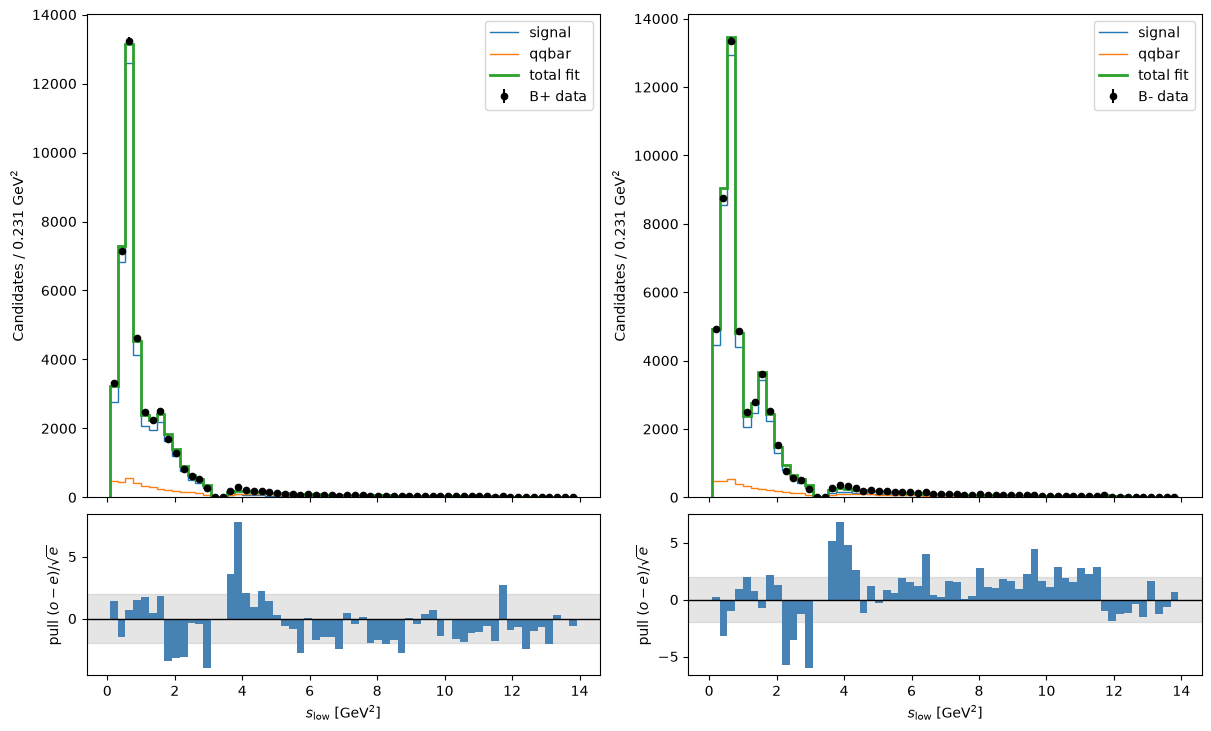

In [50]:
isobar_session.plot_projection(
    isobar_result, variable="s13", partner_variable="s23", folded=True,
    fold_side="low", bins=60, show_components=True, show_pulls=True,
    projection_size=1_000_000,
)
plt.show()


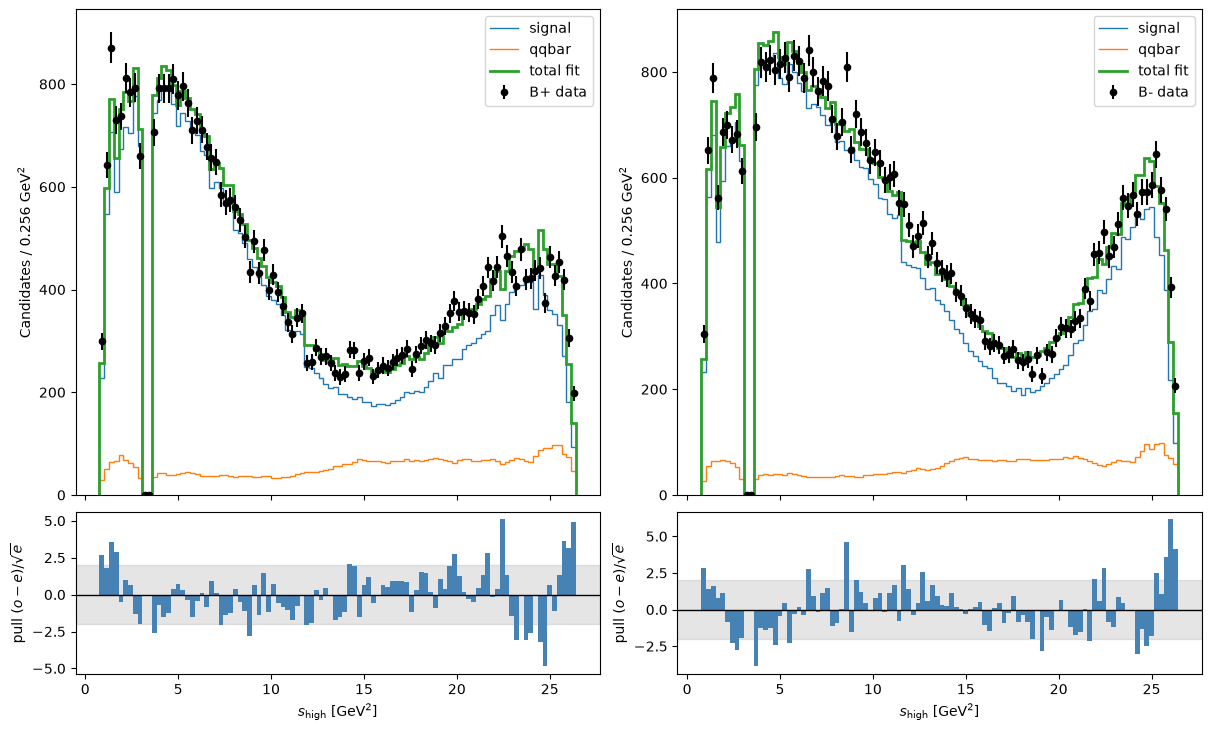

In [51]:
isobar_session.plot_projection(
    isobar_result, variable="s13", partner_variable="s23", folded=True,
    fold_side="high", bins=100, show_components=True, show_pulls=True,
    projection_size=1_000_000,
)
plt.show()


## Inicialização QMI a partir do resultado isobárico


In [52]:
def isobar_swave_single_pair(charge, mass):
    """Soma de um par, sem escalas individuais, com parâmetros do fit aos dados."""
    total = jnp.zeros_like(jnp.asarray(mass), dtype=jnp.complex128)
    for component in isobar_models[charge].amplitude_model.components:
        if component.name not in SWAVE_NAMES:
            continue
        dynamics = component.function
        total = total + component.coefficient.value(isobar_values) * dynamics.lineshape(
            jnp.asarray(mass), dynamics.context.resolve(isobar_values)
        )
    return np.asarray(total)


# QMI S-wave knots in m(pi+pi-), pair (2, 0) -- fixed list given for this fit.
QMI_KNOTS_GEV = (
    0.279140, 0.509015, 0.634185, 0.704998, 0.769832, 0.841871, 0.901300, 0.970000,
    0.980000, 0.990000, 1.000000, 1.070000, 1.133000, 1.195000, 1.250000, 1.310000,
    1.360000, 1.410000, 1.556780, 1.740000, 1.894000, 2.236000, 2.500000, 4.472130,
    4.817487, 5.139690,
)
# Linear interpolation in s=m(pi+pi-)**2, as requested for this comparison.
# Saved fit outputs must be regenerated after changing the interpolation.
QMI_INTERPOLATION = "none"  # Constant complex amplitude per mass bin.

# Optional QMI curvature penalty, as in 23_..._SqDP_QMI1D_Smoothness (docs/lineshapes.md,
# "Optional QMI knot smoothing"). QMISmoothnessConstraint rejects interpolation="none", so
# the same formula is applied to the constant bin values placed at the bin centers (see
# the session cell). NOT validated against toys here: lambda depends on the node scale
# (not comparable to notebook 23's) and post-fit errors come from the penalized objective.
# strength=0.0 is an exact no-op.
QMI_SMOOTHNESS_STRENGTH = 0.1  # lambda fixo; zero desliga a penalização
QMI_SMOOTHNESS_WEIGHTS = None  # None: only stencils entirely above the D0 veto are active;
                               # otherwise len(QMI_BIN_CENTERS)-2 weights, one per interior bin

# In step mode knots are EDGES; parameters belong to the 25 intervals.
QMI_BIN_CENTERS = (np.asarray(QMI_KNOTS_GEV[:-1]) + np.asarray(QMI_KNOTS_GEV[1:])) / 2
QMI_VETO_BINS = tuple(i for i, (lo, hi) in enumerate(zip(QMI_KNOTS_GEV[:-1], QMI_KNOTS_GEV[1:]))
                     if lo >= D0_VETO_MIN_GEV and hi <= D0_VETO_MAX_GEV)
QMI_FIXED_BINS = (0, *QMI_VETO_BINS)

_qmi_seed_amplitude = {
    charge: isobar_swave_single_pair(charge, QMI_BIN_CENTERS) for charge in (+1, -1)
}


_qmi_global_seed = {charge: complex(seed[0]) for charge, seed in _qmi_seed_amplitude.items()}
if any(not np.isfinite(value) or abs(value) < 1e-12 for value in _qmi_global_seed.values()):
    raise ValueError("Semente no primeiro nó é nula/não finita; não é possível fixá-lo em 1+0j")


from dataclasses import dataclass


@dataclass(frozen=True)
class CPBinPart:
    """Scalar x+charge*dx (or y+charge*dy), resolved by the dynamics API.

    Embedded Parameter.dynamics fields are discovered by DecayModel and
    shared across charges; resolution remains differentiable in JAX.
    """
    average: Parameter
    difference: Parameter
    charge: int

    def resolve(self, values=None):
        return self.average.resolve(values) + self.charge * self.difference.resolve(values)


normalized_seeds = {
    charge: seed / _qmi_global_seed[charge]
    for charge, seed in _qmi_seed_amplitude.items()
}
for seed in normalized_seeds.values():
    seed[0] = 1.0 + 0.0j
    seed[list(QMI_VETO_BINS)] = 0.0 + 0.0j
bin_average = (normalized_seeds[+1] + normalized_seeds[-1]) / 2
bin_difference = (normalized_seeds[+1] - normalized_seeds[-1]) / 2
QMI_BIN_CP = tuple(
    {
        key: Parameter.dynamics(
            f"S_QMI.bin_{i:02d}.{key}", float(value), owner="S_QMI",
            fixed=(i in QMI_FIXED_BINS),
            step=max(1e-5, 0.02 * max(abs(normalized_seeds[+1][i]), abs(normalized_seeds[-1][i]))),
        )
        for key, value in zip(("x", "y", "dx", "dy"),
                              (avg.real, avg.imag, diff.real, diff.imag))
    }
    for i, (avg, diff) in enumerate(zip(bin_average, bin_difference))
)


def make_qmi_lineshape(charge):
    return QMI(
        knots=QMI_KNOTS_GEV,
        real_parts=tuple(CPBinPart(p["x"], p["dx"], charge) for p in QMI_BIN_CP),
        imaginary_parts=tuple(CPBinPart(p["y"], p["dy"], charge) for p in QMI_BIN_CP),
        interpolation=QMI_INTERPOLATION,
    )


S_QMI_LINESHAPES = {charge: make_qmi_lineshape(charge) for charge in (+1, -1)}
shared_coefficients = make_shared_coefficients(isobar_values)
# c_plus = (x+dx) + i(y+dy); c_minus = (x-dx) + i(y-dy).
_c_average = (_qmi_global_seed[+1] + _qmi_global_seed[-1]) / 2
_c_difference = (_qmi_global_seed[+1] - _qmi_global_seed[-1]) / 2
shared_coefficients["S_QMI"] = CPRealImag(*(
    Parameter.coefficient(f"S_QMI.{key}", float(value), owner="S_QMI", fixed=False)
    for key, value in zip(("x", "y", "dx", "dy"),
                          (_c_average.real, _c_average.imag, _c_difference.real, _c_difference.imag))
))
dynamics_parameters = make_dynamics_parameters(isobar_values)
print(f"Independent QMI: {len(QMI_KNOTS_GEV)} masses, {4 * (len(QMI_BIN_CENTERS) - len(QMI_FIXED_BINS))} free node parameters + 4 global CP parameters")

Independent QMI: 26 masses, 92 free node parameters + 4 global CP parameters


## Onda-S de start (antes do ajuste)

Magnitude ao quadrado e fase da QMI inicial para B+ e B−, sem chi_c0, avaliadas
em uma única massa de par. Os pontos marcam os nós, com o primeiro fixo em `1+0j`;
a faixa sombreada indica o veto D0. A fase é relativa ao rho de cada carga.
As duas cargas começam de sementes distintas (mesma assimetria CP `dx, dy` do fit isobárico),
com os demais nós independentes e coeficiente CPV global livre.
Esta célula usa os valores iniciais dos parâmetros e a interpolação configurada;
não depende de `result` nem dos valores pós-fit.


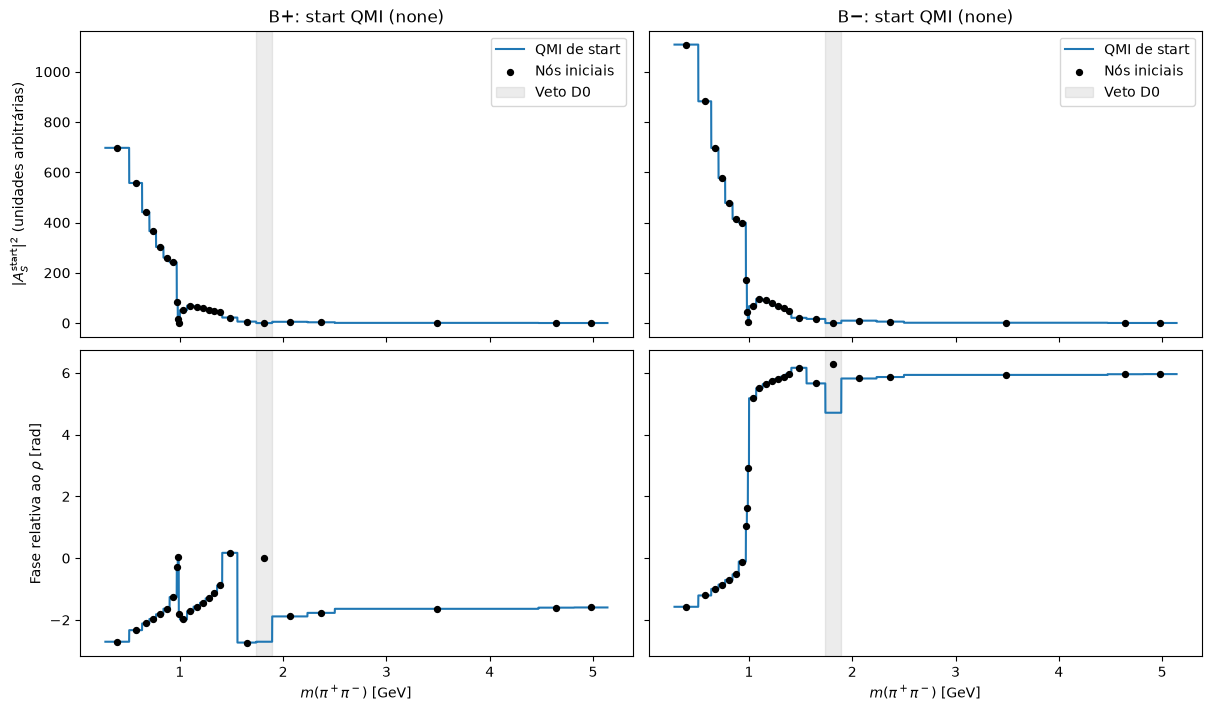

In [53]:
start_mass_scan = np.linspace(QMI_KNOTS_GEV[0], QMI_KNOTS_GEV[-1], 4000)
start_swave_curves = {}
fig_start_swave, start_axes = plt.subplots(
    2, 2, figsize=(12, 7), sharex=True, sharey="row", constrained_layout=True,
)

for col, (charge, charge_label) in enumerate(((+1, "B+"), (-1, "B−"))):
    qmi_parameters = S_QMI_LINESHAPES[charge]
    start_real = np.asarray([p.resolve({}) for p in qmi_parameters.real_parts])
    start_imag = np.asarray([p.resolve({}) for p in qmi_parameters.imaginary_parts])
    start_qmi = QMI(
        knots=qmi_parameters.knots,
        real_parts=tuple(start_real), imaginary_parts=tuple(start_imag),
        interpolation=qmi_parameters.interpolation,
    )
    start_magnitude, start_phase = start_qmi.interpolated_magnitude_phase(jnp.asarray(start_mass_scan))
    global_coefficient = complex(shared_coefficients["S_QMI"].for_charge(charge).value({}))
    reference_phase = float(jnp.angle(shared_coefficients["rho0_770"].for_charge(charge).value({})))
    # Cartesian nodes make interpolated_magnitude_phase recompute jnp.angle(re + i*im) at
    # every scan point, wrapped to (-pi, pi]; unwrap so the plotted curve stays continuous
    # instead of showing spurious ~2*pi jumps wherever the physical phase crosses the cut.
    start_phase = np.unwrap(np.angle(global_coefficient * np.exp(1j * np.asarray(start_phase)))) - reference_phase
    start_intensity = abs(global_coefficient) ** 2 * np.asarray(start_magnitude) ** 2
    start_swave_curves[charge_label] = {
        "mass_GeV": start_mass_scan, "intensity": start_intensity, "phase_rad": start_phase,
    }
    start_node_intensity = abs(global_coefficient) ** 2 * (start_real ** 2 + start_imag ** 2)
    # Unwrap across knots (increasing mass order) so markers land on the unwrapped curve
    # above instead of off it by a multiple of 2*pi at whichever knot the wrap cut falls on.
    start_node_phase = np.unwrap(np.angle(global_coefficient * (start_real + 1j * start_imag))) - reference_phase

    start_axes[0, col].plot(start_mass_scan, start_intensity, label="QMI de start")
    start_axes[0, col].scatter(QMI_BIN_CENTERS, start_node_intensity,
                               s=18, color="black", zorder=3, label="Nós iniciais")
    start_axes[1, col].plot(start_mass_scan, start_phase)
    start_axes[1, col].scatter(QMI_BIN_CENTERS, start_node_phase,
                               s=18, color="black", zorder=3)
    for row in (0, 1):
        start_axes[row, col].axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV,
                                    color="grey", alpha=0.15, label="Veto D0")
    start_axes[0, col].set_title(f"{charge_label}: start QMI ({qmi_parameters.interpolation})")
    start_axes[0, col].legend()
    start_axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")

start_axes[0, 0].set_ylabel(r"$|A_S^{\mathrm{start}}|^2$ (unidades arbitrárias)")
start_axes[1, 0].set_ylabel(r"Fase relativa ao $\rho$ [rad]")
plt.show()


## Componentes do modelo QMI

Os seis isóbaros restantes e `S_QMI` usam `normalize_component=False`; ambos os
modelos usam `normalize_components=False`, assim como no fit isobárico anterior.
O coeficiente externo da QMI é CPRealImag livre; o primeiro bin é fixo em `1+0j` por carga.
A densidade total continua normalizada conjuntamente para B+ e B−, incluindo interferências.


In [54]:
def build_components(charge, shared, dynamics):
    coefficient = {name: cp.for_charge(charge) for name, cp in shared.items()}
    components = [
        Resonance(
            name, RESONANCE_PAIR, coefficient[name],
            lineshape=LINESHAPES[name](), angular=ZemachP(),
            normalize_component=False,
            mass=dynamics[f"{name}.mass"], width=dynamics[f"{name}.width"], spin=SPINS[name],
            resonance_radius=4.0, parent_radius=4.0,
        )
        for name in LINESHAPES if name not in SWAVE_NAMES
    ]
    components.append(
        Resonance(
            "S_QMI", RESONANCE_PAIR, coefficient["S_QMI"],
            lineshape=S_QMI_LINESHAPES[charge], angular=ZemachP(),
            normalize_component=False,
            mass=1.0, width=0.0, spin=0,
            resonance_radius=4.0, parent_radius=4.0,
        )
    )
    return components


plus_model = DecayModel(
    PLUS_CHANNEL, build_components(+1, shared_coefficients, dynamics_parameters),
    normalize_components=False,
    **NORMALIZATION_CONFIG
)
minus_model = DecayModel(
    MINUS_CHANNEL, build_components(-1, shared_coefficients, dynamics_parameters),
    normalize_components=False,
    **NORMALIZATION_CONFIG
)

print("B+ components:", [c.name for c in plus_model.amplitude_model.components])
print("B+ normalization sample size:", plus_model.normalization_sample.size)

B+ components: ['rho0_770', 'omega_782', 'rho0_1450', 'f2_1270', 'rho0_3_1690', 'chi_c0', 'S_QMI']
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
B+ normalization sample size: 1000000


## Backgrounds nos dois ajustes

`make_data_fit_session` usa a quadratura de cada modelo para normalizar os
backgrounds pós-veto e aplicar as assimetrias fixas. Os dois fits usam os mesmos yields.


A sessão QMI abaixo reutiliza a mesma configuração experimental do fit isobárico.


In [55]:
# Backgrounds configurados por make_data_fit_session na célula seguinte.


## Sessão de ajuste CP

Ajuste estendido: `signal_yield` = `N_signal` fixo (o `signalAsym` do Laura++ não entra na
verossimilhança porque o DP está no ajuste, ver acima), background `qqbar` com yield total fixo e
a assimetria embutida nas formas `plus`/`minus` construídas acima. `kpipibkg` também é registrado,
com `yield_=0` fixo (inerte, ver acima).

In [56]:
fit_session = make_data_fit_session(plus_model, minus_model)

# Step QMI: bin values sit at the bin centers of an auxiliary "linear" QMI that shares the
# same CPBinPart parameters. It only feeds the penalty; the fitted amplitude stays constant
# per bin. By default only the region after the D0 veto is smoothed: weight k is the
# stencil of bins (k, k+1, k+2), active only if all three lie above the veto bin (fixed at 0).
if QMI_SMOOTHNESS_WEIGHTS is None:
    QMI_SMOOTHNESS_WEIGHTS = tuple(
        1.0 if k > max(QMI_VETO_BINS) else 0.0 for k in range(len(QMI_BIN_CENTERS) - 2)
    )


def qmi_bin_smoothness(charge):
    step_qmi = S_QMI_LINESHAPES[charge]
    centers_qmi = QMI(knots=tuple(float(m) for m in QMI_BIN_CENTERS),
                      real_parts=step_qmi.real_parts, imaginary_parts=step_qmi.imaginary_parts,
                      interpolation="linear")
    return centers_qmi.smoothness_constraint(strength=QMI_SMOOTHNESS_STRENGTH,
                                             weights=QMI_SMOOTHNESS_WEIGHTS)


# Preserve the original penalty on the physical nodes c_q * QMI_q.
# The curvature penalty is quadratic, so multiply the shape penalty by |c_q|².
def physical_qmi_smoothness(charge):
    shape_penalty = qmi_bin_smoothness(charge)
    coefficient = shared_coefficients["S_QMI"].for_charge(charge)

    def penalty(fit_values):
        return jnp.abs(coefficient.value(fit_values)) ** 2 * shape_penalty(fit_values)

    return penalty


QMI_SMOOTHNESS_CONSTRAINTS = tuple(physical_qmi_smoothness(charge) for charge in (+1, -1))
for penalty in QMI_SMOOTHNESS_CONSTRAINTS:
    fit_session = fit_session.with_constraint(penalty)

n_free = sum(1 for p in fit_session.parameters if not p.fixed)
n_fixed = sum(1 for p in fit_session.parameters if p.fixed)
print(f"parameters: {len(fit_session.parameters)} total, {n_free} free, {n_fixed} fixed")
print("S_QMI: 25 constant bins (re+im) per charge; first bin fixed at 1+0j and D0 bin fixed at 0; global x/y/dx/dy free")
print(f"QMI smoothness strength: {QMI_SMOOTHNESS_STRENGTH} (unvalidated -- see cell above)")
print(f"QMI smoothness weights: {QMI_SMOOTHNESS_WEIGHTS}")
assert n_free == 4 * (len(QMI_BIN_CENTERS) - len(QMI_FIXED_BINS)) + 4 + 21  # shape nodes + global S CP + other coefficients

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
parameters: 143 total, 117 free, 26 fixed
S_QMI: 25 constant bins (re+im) per charge; first bin fixed at 1+0j and D0 bin fixed at 0; global x/y/dx/dy free
QMI smoothness strength: 0.1 (unvalidated -- see cell above)
QMI smoothness weights: (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0)


In [57]:
for p in fit_session.parameters:
    print(f"{p.name:24s} value={p.value: .6g}  fixed={p.fixed}")


rho0_770.x               value= 1  fixed=True
rho0_770.y               value= 0  fixed=True
rho0_770.dx              value= 0.000918227  fixed=False
rho0_770.dy              value= 0  fixed=True
rho0_770.mass            value= 0.770229  fixed=True
rho0_770.width           value= 0.148864  fixed=True
omega_782.x              value=-0.00792312  fixed=False
omega_782.y              value= 0.0247296  fixed=False
omega_782.dx             value= 0.0018496  fixed=False
omega_782.dy             value= 0.00361415  fixed=False
omega_782.mass           value= 0.78265  fixed=True
omega_782.width          value= 0.00849  fixed=True
rho0_1450.x              value=-0.608017  fixed=False
rho0_1450.y              value= 0.254641  fixed=False
rho0_1450.dx             value=-0.203741  fixed=False
rho0_1450.dy             value=-0.0175133  fixed=False
rho0_1450.mass           value= 1.465  fixed=True
rho0_1450.width          value= 0.4  fixed=True
f2_1270.x                value= 0.0779936  fixed=False
f2_

## Ajuste QMI

O fit isobárico aos dados inicializa os coeficientes preservados e os nós QMI.
MIGRAD usa estratégia 1 e HESSE com Hessiana JAX. Verificamos a convergência e
a covariância antes dos diagnósticos. Múltiplos starts ainda podem explorar outros mínimos.


In [58]:
qmi_multifit = fit_session.fit_multistart(
    n_starts=N_STARTS,
    seed=20260924,
    include_default=True,
    strategy=2,
    verbose=1,
    hessian="jax",
)
result = qmi_multifit.best
print(result.fmin)
if not result.valid or result.covariance is None or not result.fmin.has_accurate_covar:
    raise RuntimeError("Fit/covariance not reliable: inspect MIGRAD, EDM and HESSE before reporting errors")
# As in notebook 23: fval includes the penalty; report data NLL and penalty separately.
_fit_values = fit_session.result_values(result)
nll_data = float(fit_session.base_objective(_fit_values))
smoothness_penalty = float(sum(penalty(_fit_values) for penalty in QMI_SMOOTHNESS_CONSTRAINTS))
print(f"nll = {result.fval:.3f}   nll_data = {nll_data:.3f}   smoothness_penalty = {smoothness_penalty:.3f}")

[Minimizer] multistart with 117 free parameters, 1 starts (simplex=False, strategy=2, seed=20260924)
[Minimizer] start 1/1 running
[Minimizer] MIGRAD 1 started


/Users/juanleite/Work/DalitzPlotFitter/.venv/lib/python3.13/site-packages/iminuit/minuit.py:733: IMinuitWarning: hessian overrides g2, passing g2 has no effect
  warnings.warn(


[Minimizer] MIGRAD 1 finished in 42.329 s: nfcn=+103, ngrad=+43, nhessian=+4
[Minimizer] MIGRAD 2 started
[Minimizer] MIGRAD 2 finished in 7.961 s: nfcn=+2, ngrad=+2, nhessian=+2
[Minimizer] start 1/1 finished: valid=True  NLL=-491891.894524  EDM=8.052e-17  nfcn=105
[Minimizer] selected start 1/1 for strategy-2/HESSE refinement: valid=True  NLL=-491891.894524  EDM=8.052e-17  nfcn=105
[Minimizer] MIGRAD 1 started


/Users/juanleite/Work/DalitzPlotFitter/.venv/lib/python3.13/site-packages/iminuit/minuit.py:733: IMinuitWarning: hessian overrides g2, passing g2 has no effect
  warnings.warn(


[Minimizer] MIGRAD 1 finished in 0.224 s: nfcn=+6, ngrad=+1, nhessian=+3
[Minimizer] MIGRAD 2 started
[Minimizer] MIGRAD 2 finished in 0.264 s: nfcn=+6, ngrad=+1, nhessian=+2
[Minimizer] HESSE started
[Minimizer] HESSE finished in 0.005 s: nfcn=+0, ngrad=+0, nhessian=+1
[Minimizer] final refined minimum: valid=True  NLL=-491891.894524  EDM=8.052e-17  nfcn=12
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -4.919e+05                 │  Nfcn = 12, Ngrad = 2, Nhessian = 6  │
│ EDM = 8.05e-17 (Goal: 1e-07)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit  

In [59]:
values = fit_session.print_result(result)


valid=True  NLL=-491891.894524
parameter                           value            error
rho0_770.x                              1                0
rho0_770.y                              0                0
rho0_770.dx                    -0.0125464       0.00504639
rho0_770.dy                             0                0
rho0_770.mass                    0.770229                0
rho0_770.width                   0.148864                0
omega_782.x                   -0.00753677       0.00111202
omega_782.y                     0.0252251       0.00100529
omega_782.dx                     0.002105       0.00112654
omega_782.dy                   0.00248277      0.000989269
omega_782.mass                    0.78265                0
omega_782.width                   0.00849                0
rho0_1450.x                     -0.572821        0.0226112
rho0_1450.y                      0.396187        0.0192788
rho0_1450.dx                    -0.108001        0.0234506
rho0_1450.dy             

## Referência isobárica local

Os parâmetros do log Laura++ abaixo pertencem a outro modelo de onda-S. A tabela é apenas
uma referência dos valores isobáricos; não é um teste de pull ou de fechamento QMI.
Os dois fits usam os mesmos dados, portanto suas estimativas também são correlacionadas.

In [60]:
LAURA_FINAL = {
    "rho0_770.x": (1.00000e+00, 0.0), "rho0_770.y": (0.00000e+00, 0.0),
    "rho0_770.dx": (1.02312e-03, 3.60608e-03), "rho0_770.dy": (0.00000e+00, 0.0),
    "omega_782.x": (-3.03268e-02, 4.34944e-03), "omega_782.y": (9.48849e-02, 4.14539e-03),
    "omega_782.dx": (7.29877e-03, 4.07079e-03), "omega_782.dy": (1.38260e-02, 3.60962e-03),
    "rho0_1450.x": (-2.70865e-01, 6.46501e-03), "rho0_1450.y": (1.13529e-01, 5.70862e-03),
    "rho0_1450.dx": (-9.16491e-02, 6.14297e-03), "rho0_1450.dy": (-7.71941e-03, 5.37036e-03),
    "f2_1270.x": (3.51291e-01, 5.34772e-03), "f2_1270.y": (1.71931e-01, 5.93363e-03),
    "f2_1270.dx": (-5.45892e-02, 4.56093e-03), "f2_1270.dy": (-1.17944e-01, 5.02792e-03),
    "rho0_3_1690.x": (9.64994e-02, 3.98479e-03), "rho0_3_1690.y": (1.91968e-02, 5.36046e-03),
    "rho0_3_1690.dx": (4.92371e-02, 3.92311e-03), "rho0_3_1690.dy": (5.41424e-02, 5.23042e-03),
    "sigma0.x": (-4.02003e-01, 8.67937e-03), "sigma0.y": (3.57099e-01, 8.00027e-03),
    "sigma0.dx": (2.86690e-01, 5.95293e-03), "sigma0.dy": (2.01322e-01, 7.59760e-03),
    "f0_980.x": (1.41060e-01, 4.21299e-03), "f0_980.y": (-1.40500e-02, 5.84319e-03),
    "f0_980.dx": (-4.50930e-02, 4.83089e-03), "f0_980.dy": (-7.70899e-02, 3.92358e-03),
    "chi_c0.x": (2.71432e-02, 4.79001e-03), "chi_c0.y": (1.41733e-02, 5.83786e-03),
    "chi_c0.dx": (-4.02037e-02, 4.84198e-03), "chi_c0.dy": (-4.02666e-02, 5.88143e-03),
    "f0_1370.x": (1.00608e-01, 4.83099e-03), "f0_1370.y": (-2.34739e-02, 7.37598e-03),
    "f0_1370.dx": (5.11699e-02, 5.95883e-03), "f0_1370.dy": (-5.63136e-02, 4.65568e-03),
    "rho0_770.mass": (7.70229e-01, 5.99753e-04), "rho0_770.width": (1.48864e-01, 1.44233e-03),
    "f2_1270.mass": (1.25071e+00, 1.43721e-03), "f2_1270.width": (1.70502e-01, 3.35104e-03),
    "sigma0.mass": (5.09084e-01, 6.99672e-03), "sigma0.width": (4.25813e-01, 8.89256e-03),
    "f0_980.mass": (9.76535e-01, 1.07026e-03), "f0_980.width": (4.77831e-02, 2.61757e-03),
    "f0_1370.mass": (1.50218e+00, 6.70858e-03), "f0_1370.width": (1.73547e-01, 1.35102e-02),
}

rows = []
for p in fit_session.parameters:
    if p.name not in LAURA_FINAL:
        continue
    laura_value, laura_error = LAURA_FINAL[p.name]
    our_value = values[p.name]
    our_error = 0.0 if p.fixed else float(result.errors[p.name])
    rows.append({
        "parameter": p.name,
        "fixed": p.fixed,
        "our value": our_value,
        "our error": our_error,
        "Laura value": laura_value,
        "Laura error": laura_error,
        "difference (not a pull)": our_value - laura_value,
    })

comparison = pd.DataFrame(rows).set_index("parameter")
pd.set_option("display.float_format", lambda x: f"{x: .6g}")
comparison

,fixed,our value,our error,Laura value,Laura error,difference (not a pull)
parameter,,,,,,
rho0_770.x,True,1,0,1,0,0
rho0_770.y,True,0,0,0,0,0
rho0_770.dx,False,-0.0125464,0.00504639,0.00102312,0.00360608,-0.0135695
rho0_770.dy,True,0,0,0,0,0
rho0_770.mass,True,0.770229,0,0.770229,0.000599753,0
rho0_770.width,True,0.148864,0,0.148864,0.00144233,0
omega_782.x,False,-0.00753677,0.00111202,-0.0303268,0.00434944,0.02279
omega_782.y,False,0.0252251,0.00100529,0.0948849,0.00414539,-0.0696598
omega_782.dx,False,0.002105,0.00112654,0.00729877,0.00407079,-0.00519377


## Fit fractions físicas por carga

Integrais no DP completo, sem eficiência/veto, com `integral(f)=mean(weights*f)`.
A FF da onda-S é a da amplitude QMI simetrizada, sem chi_c0. Comparar com uma soma
isobárica exige incluir suas interferências. A FF CP média é ponderada pelas taxas R±.

In [61]:
component_names = [c.name for c in plus_model.amplitude_model.components]
# Physical caches exclude efficiency/veto; accepted charge fractions must not replace these rates.
physical_caches = {
    charge: model.prepare_cache(model.normalization_sample.take(jnp.arange(1)))
    for charge, model in (("plus", plus_model), ("minus", minus_model))
}


def physical_component_rates(cache, fit_values):
    matrix = cache.normalization_matrix(fit_values)
    coefficients = cache.coefficient_vector(fit_values)
    rates = jnp.abs(coefficients) ** 2 * jnp.real(jnp.diag(matrix))
    total = jnp.real(jnp.vdot(coefficients, matrix @ coefficients))
    return rates, total


physical_rates = {q: physical_component_rates(cache, values) for q, cache in physical_caches.items()}
fit_fractions = {
    q: dict(zip(component_names, map(float, rates / total)))
    for q, (rates, total) in physical_rates.items()
}
physical_ff_cp = dict(zip(component_names, map(float,
    (physical_rates["plus"][0] + physical_rates["minus"][0])
    / (physical_rates["plus"][1] + physical_rates["minus"][1]))))
print("R_plus =", float(physical_rates["plus"][1]), "R_minus =", float(physical_rates["minus"][1]))
display(pd.DataFrame(fit_fractions) * 100.0)

R_plus = 140272.39847524365 R_minus = 165321.91912583628


,plus,minus
rho0_770,61.1671,54.5702
omega_782,0.736399,0.478219
rho0_1450,9.21987,3.08318
f2_1270,6.51533,12.8278
rho0_3_1690,1.29334,0.311
chi_c0,0.108753,0.449291
S_QMI,19.8654,24.9272


In [62]:
def _ff_asymmetry_percent(plus_ff, minus_ff):
    return {
        name: 100.0 * (minus_ff[name] - plus_ff[name]) / (minus_ff[name] + plus_ff[name])
        for name in plus_ff
    }


component_names = [c.name for c in plus_model.amplitude_model.components]
plus_ff_pct = {n: 100.0 * fit_fractions["plus"][n] for n in component_names}
minus_ff_pct = {n: 100.0 * fit_fractions["minus"][n] for n in component_names}

our_table = pd.DataFrame({
    "B- FF [%]": minus_ff_pct,
    "B+ FF [%]": plus_ff_pct,
    "FF asym [%]": _ff_asymmetry_percent(plus_ff_pct, minus_ff_pct),
})
our_table


,B- FF [%],B+ FF [%],FF asym [%]
rho0_770,54.5702,61.1671,-5.69983
omega_782,0.478219,0.736399,-21.256
rho0_1450,3.08318,9.21987,-49.8794
f2_1270,12.8278,6.51533,32.634
rho0_3_1690,0.311,1.29334,-61.2303
chi_c0,0.449291,0.108753,61.0236
S_QMI,24.9272,19.8654,11.3007


### ACP integrado por componente

`ACP = (I_minus - I_plus)/(I_minus + I_plus)`, com as integrais físicas de cada
componente. Para a QMI independente, entram os nós de ambas as cargas. A incerteza
propaga a covariância conjunta de todos os parâmetros livres, incluindo dinâmica.

In [63]:
def component_acp_percent(fit_values):
    plus_rates, _ = physical_component_rates(physical_caches["plus"], fit_values)
    minus_rates, _ = physical_component_rates(physical_caches["minus"], fit_values)
    return 100.0 * (minus_rates - plus_rates) / (minus_rates + plus_rates)


free_parameter_names = [p.name for p in fit_session.parameters if not p.fixed]
acp_errors = delta_method_errors(component_acp_percent, values, free_parameter_names, result.covariance)
acp_table = pd.DataFrame({
    "ACP [%]": np.asarray(component_acp_percent(values)),
    "sigma(ACP)": np.asarray(acp_errors),
}, index=component_names)
display(acp_table)
# These extra caches are only needed for physical observable derivatives, not fit evaluation.
del physical_caches

,ACP [%],sigma(ACP)
rho0_770,2.50888,1.00881
omega_782,-13.2906,7.85626
rho0_1450,-43.4593,3.90502
f2_1270,39.7673,2.17279
rho0_3_1690,-55.8357,6.5306
chi_c0,65.9231,6.80865
S_QMI,19.3187,1.36242


## Comparação com a tabela fornecida: coeficientes globais (NLL 967471)

Os valores de `A_i` são tratados como **magnitudes dos coeficientes globais**,
conforme esclarecido pelo usuário: não aplicamos quadrado, raiz ou fator `10⁻²`
a essas colunas, apesar do cabeçalho da imagem. Esta tabela é distinta das tabelas
do draft apresentadas a seguir. A tabela de onda-S por bin também permanece separada.

Comparamos FF por carga, FF média e ACP integrado, além de magnitude e fase dos seis
coeficientes isobáricos (fase relativa ao rho). Exibimos tanto a FF média aritmética
quanto a ponderada pelas taxas, pois a imagem não define `<FF>` explicitamente.
As magnitudes são coeficientes da nossa base **sem normalização individual**; sua
comparação direta pressupõe a mesma convenção de escala das funções na referência.

Nesta cópia, S-wave também entra nos gráficos e tabelas de coeficientes globais.
Sua magnitude/fase são definidas pela convenção de primeiro bin `1+0j`.
A comparação direta pressupõe a mesma convenção para a forma QMI da referência.
Não calculamos pulls entre fits nem comparamos NLLs sem confirmar as convenções.


,FF B+ nosso [%],FF B+ tabela [%],FF B- nosso [%],FF B- tabela [%],FF média aritmética nosso [%],FF ponderada nosso [%],FF média tabela [%],ACP nosso [%],erro ACP nosso [%],ACP tabela [%],erro ACP tabela [%]
rho0_770,61.1671,61.7,54.5702,53.6,57.8686,57.5983,57.3,2.50888,1.00881,1.4,1.1
omega_782,0.736399,0.7,0.478219,0.5,0.607309,0.596728,0.6,-13.2906,7.85626,-12.7,7.9
rho0_1450,9.21987,7.1,3.08318,4,6.15152,5.90001,5.4,-43.4593,3.90502,-19.7,6.2
f2_1270,6.51533,6.3,12.8278,12.7,9.67155,9.93027,9.8,39.7673,2.17279,40.7,2.3
rho0_3_1690,1.29334,0.6,0.311,0.2,0.802173,0.761911,0.4,-55.8357,6.5306,-37.8,9.7
chi_c0,0.108753,0.1,0.449291,0.4,0.279022,0.292979,0.3,65.9231,6.80865,71,7.1
S_QMI,19.8654,20.4,24.9272,26.4,22.3963,22.6038,23.7,19.3187,1.36242,18.4,1.7


,nosso,tabela (soma impressa)
Soma FF ponderada/média [%],97.6839,97.4
Soma FF B- [%],96.6469,97.9
Soma FF B+ [%],98.9061,96.9


magnitude nosso  magnitude tabela  erro magnitude tabela  \
component   charge                                                             
rho0_770    plus           0.987454              0.99                   0.01   
            minus           1.01255              1.01                   0.01   
omega_782   plus          0.0282353              0.03                      0   
            minus         0.0247018              0.02                      0   
rho0_1450   plus           0.857321              0.68                   0.03   
            minus           0.53822              0.56                   0.04   
f2_1270     plus          0.0715935               0.8                   0.02   
            minus          0.109059              1.23                   0.03   
rho0_3_1690 plus         0.00680788              0.23                   0.01   
            minus        0.00362422              0.15                   0.02   
chi_c0      plus           0.259333                 0                      0   
            minus          0.572244                 0                      0   
S_QMI       plus            29.3791              2.35                   0.05   
            minus           35.0164              1.55                   0.05   

                    fase nosso [deg]  fase tabela [deg]  \
component   charge                                        
rho0_770    plus                   0                  0   
            minus                  0                  0   
omega_782   plus             101.091                102   
            minus            112.975                113   
rho0_1450   plus             142.573                129   
            minus            149.726                150   
f2_1270     plus             2.52321                  2   
            minus            34.5214                 42   
rho0_3_1690 plus             15.9881                  2   
            minus           -35.9732                -39   
chi_c0      plus            -80.5776                -68   
            minus            57.2504                 70   
S_QMI       plus            -128.821                -85   
            minus           -87.3685                -80   

                    erro fase tabela [deg]  diferença fase [deg]  
component   charge                                                
rho0_770    plus                         0                     0  
            minus                        0                     0  
omega_782   plus                         3             -0.908539  
            minus                        4            -0.0251476  
rho0_1450   plus                         3               13.5729  
            minus                        3             -0.274047  
f2_1270     plus                         3               0.52321  
            minus                        2              -7.47861  
rho0_3_1690 plus                         8               13.9881  
            minus                       10               3.02684  
chi_c0      plus                        15              -12.5776  
            minus                        6              -12.7496  
S_QMI       plus                         0              -43.8207  
            minus                        0              -7.36852

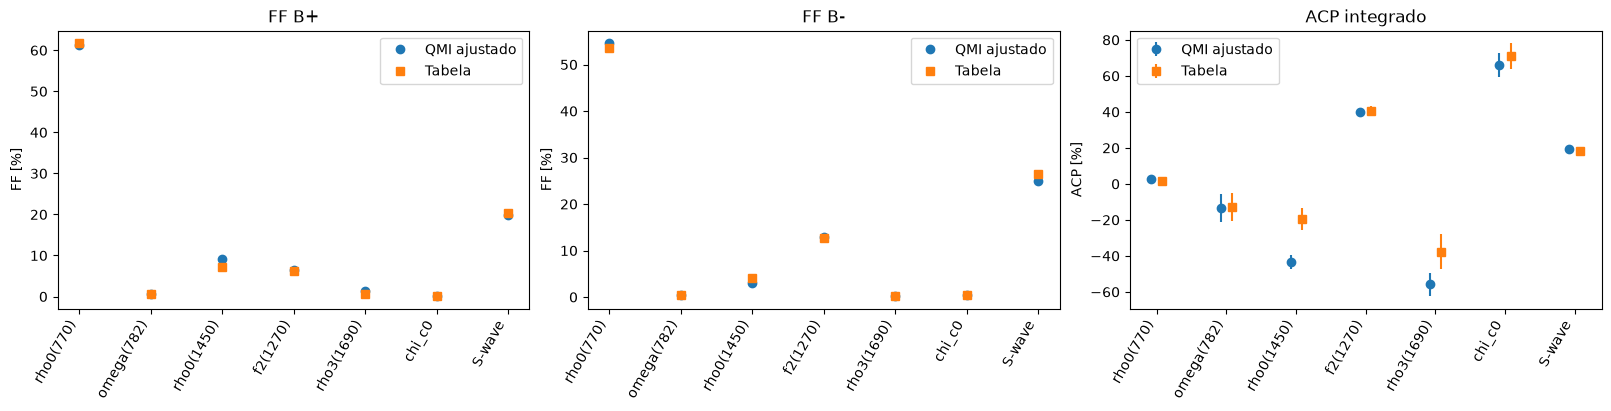

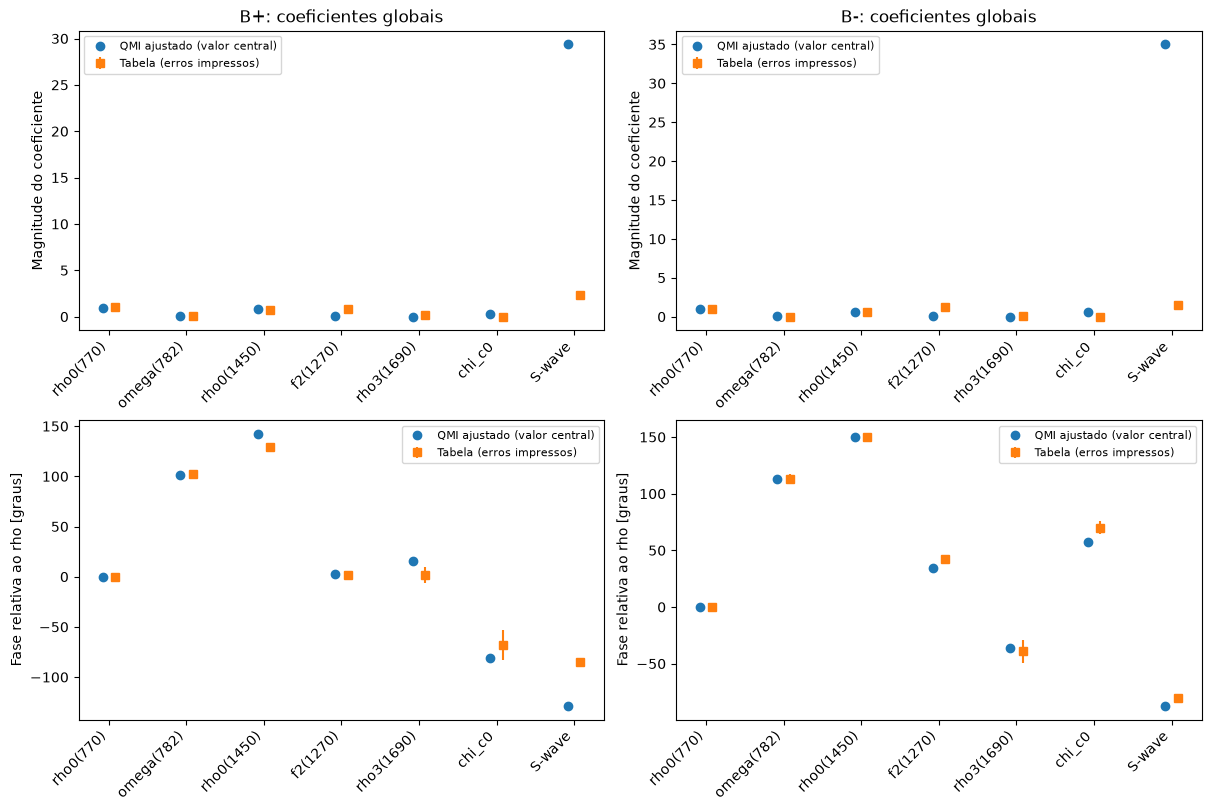

In [64]:
REFERENCE_TABLE_NAMES = {
    "rho0_770": "rho0(770)", "omega_782": "omega(782)", "rho0_1450": "rho0(1450)",
    "f2_1270": "f2(1270)", "rho0_3_1690": "rho3(1690)", "chi_c0": "chi_c0", "S_QMI": "S-wave",
}


def _wrap_deg(angle_deg):
    return (np.asarray(angle_deg) + 180.0) % 360.0 - 180.0


def coefficient_at(name, charge, fit_values):
    return shared_coefficients[name].for_charge(charge).value(fit_values)


# Transcrição da imagem; magnitudes interpretadas conforme esclarecimento do usuário.
# FF média, FF B-, FF B+, mag+, erro, fase+, erro, mag-, erro, fase-, erro, ACP, erro.
GLOBAL_REFERENCE = pd.DataFrame([
    [57.3, 53.6, 61.7, .99, .01, 0, 0, 1.01, .01, 0, 0, 1.4, 1.1],
    [0.6, 0.5, 0.7, .03, .00, 102, 3, .02, .00, 113, 4, -12.7, 7.9],
    [5.4, 4.0, 7.1, .68, .03, 129, 3, .56, .04, 150, 3, -19.7, 6.2],
    [9.8, 12.7, 6.3, .80, .02, 2, 3, 1.23, .03, 42, 2, 40.7, 2.3],
    [0.4, 0.2, 0.6, .23, .01, 2, 8, .15, .02, -39, 10, -37.8, 9.7],
    [0.3, 0.4, 0.1, .00, .00, -68, 15, .00, .00, 70, 6, 71.0, 7.1],
    [23.7, 26.4, 20.4, 2.35, .05, -85, 0, 1.55, .05, -80, 0, 18.4, 1.7],
], index=list(REFERENCE_TABLE_NAMES), columns=[
    "ff_average", "ff_minus", "ff_plus", "mag_plus", "mag_plus_error", "phase_plus", "phase_plus_error",
    "mag_minus", "mag_minus_error", "phase_minus", "phase_minus_error", "acp", "acp_error",
])
# Zeros de magnitude/erro são arredondados na imagem, não precisão infinita.
global_observable_comparison = pd.DataFrame({
    "FF B+ nosso [%]": plus_ff_pct, "FF B+ tabela [%]": GLOBAL_REFERENCE.ff_plus,
    "FF B- nosso [%]": minus_ff_pct, "FF B- tabela [%]": GLOBAL_REFERENCE.ff_minus,
    "FF média aritmética nosso [%]": {k: (plus_ff_pct[k] + minus_ff_pct[k]) / 2 for k in component_names},
    "FF ponderada nosso [%]": {k: 100 * physical_ff_cp[k] for k in component_names},
    "FF média tabela [%]": GLOBAL_REFERENCE.ff_average,
    "ACP nosso [%]": acp_table["ACP [%]"], "erro ACP nosso [%]": acp_table["sigma(ACP)"],
    "ACP tabela [%]": GLOBAL_REFERENCE.acp, "erro ACP tabela [%]": GLOBAL_REFERENCE.acp_error,
}).reindex(GLOBAL_REFERENCE.index)
display(global_observable_comparison)
display(pd.DataFrame({
    "nosso": [sum(physical_ff_cp.values()) * 100, sum(minus_ff_pct.values()), sum(plus_ff_pct.values())],
    "tabela (soma impressa)": [97.4, 97.9, 96.9],
}, index=["Soma FF ponderada/média [%]", "Soma FF B- [%]", "Soma FF B+ [%]"]))

coefficient_rows = []
for name in GLOBAL_REFERENCE.index:
    for charge, suffix in ((+1, "plus"), (-1, "minus")):
        coef = complex(coefficient_at(name, charge, values))
        rho = complex(coefficient_at("rho0_770", charge, values))
        mag = abs(coef)
        phase = float(_wrap_deg(np.degrees(np.angle(coef / rho))))
        ref = GLOBAL_REFERENCE.loc[name]
        coefficient_rows.append({
            "component": name, "charge": suffix, "magnitude nosso": mag,
            "magnitude tabela": ref[f"mag_{suffix}"], "erro magnitude tabela": ref[f"mag_{suffix}_error"],
            "fase nosso [deg]": phase, "fase tabela [deg]": ref[f"phase_{suffix}"],
            "erro fase tabela [deg]": ref[f"phase_{suffix}_error"],
            "diferença fase [deg]": float(_wrap_deg(phase - ref[f"phase_{suffix}"])),
        })
global_coefficient_comparison = pd.DataFrame(coefficient_rows).set_index(["component", "charge"])
display(global_coefficient_comparison)

names = list(GLOBAL_REFERENCE.index)
x = np.arange(len(names))
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for ax, suffix, ours in zip(axes[:2], ("plus", "minus"), (plus_ff_pct, minus_ff_pct)):
    ax.plot(x, [ours[k] for k in names], "o", label="QMI ajustado")
    ax.plot(x, GLOBAL_REFERENCE[f"ff_{suffix}"], "s", label="Tabela")
    ax.set_title(f"FF B{'+' if suffix == 'plus' else '-'}")
    ax.set_ylabel("FF [%]")
axes[2].errorbar(x - .08, acp_table.loc[names, "ACP [%]"], yerr=acp_table.loc[names, "sigma(ACP)"],
                 fmt="o", label="QMI ajustado")
axes[2].errorbar(x + .08, GLOBAL_REFERENCE.acp, yerr=GLOBAL_REFERENCE.acp_error, fmt="s", label="Tabela")
axes[2].set_title("ACP integrado")
axes[2].set_ylabel("ACP [%]")
for ax in axes:
    ax.set_xticks(x, [REFERENCE_TABLE_NAMES[k] for k in names], rotation=60, ha="right")
    ax.legend()
plt.show()

isobar_names = list(names)  # Includes the fitted global S-wave coefficient.
x = np.arange(len(isobar_names))
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for col, suffix in enumerate(("plus", "minus")):
    frame = global_coefficient_comparison.xs(suffix, level="charge").loc[isobar_names]
    for row, (our_col, ref_col, err_col, label) in enumerate((
        ("magnitude nosso", "magnitude tabela", "erro magnitude tabela", "Magnitude do coeficiente"),
        ("fase nosso [deg]", "fase tabela [deg]", "erro fase tabela [deg]", "Fase relativa ao rho [graus]"),
    )):
        ax = axes[row, col]
        ax.plot(x - .08, frame[our_col], "o", label="QMI ajustado (valor central)")
        ax.errorbar(x + .08, frame[ref_col], yerr=frame[err_col], fmt="s", label="Tabela (erros impressos)")
        ax.set_ylabel(label)
        ax.set_xticks(x, [REFERENCE_TABLE_NAMES[k] for k in isobar_names], rotation=45, ha="right")
        ax.legend(fontsize=8)
    axes[0, col].set_title(f"B{'+' if suffix == 'plus' else '-'}: coeficientes globais")
plt.show()


### Comparação com as tabelas do draft

A Tabela 9 é a referência para FF_CP e ACP, incluindo a onda-S integrada.
A Tabela 23 permite uma comparação exploratória das fases dos isóbaros relativas ao rho;
a linha agregada S-wave não define a curva QMI. As magnitudes dessa tabela e dos CSVs
não têm equivalência demonstrada com a convenção deste notebook e não são equiparadas.

In [65]:
# Tabela 9 ("QMI - Fit Fractions and ACP for QMI model 212-112") do rascunho
# amanr2pipipi_paper_draft.pdf -- FF em %, ACP em % com incerteza (so estatistica, sem sistematica
# separada nessa tabela).
PAPER_TABLE9_QMI = {
    "rho0(770)": dict(ff_percent=56.9, acp_percent=0.2, acp_err_percent=1.3),
    "omega(782)": dict(ff_percent=0.7, acp_percent=-10.4, acp_err_percent=7.5),
    "rho0(1450)": dict(ff_percent=6.2, acp_percent=-28.9, acp_err_percent=4.9),
    "f2(1270)": dict(ff_percent=9.8, acp_percent=36.4, acp_err_percent=2.3),
    "rho3(1690)": dict(ff_percent=0.7, acp_percent=-65.5, acp_err_percent=6.0),
    "chi_c0": dict(ff_percent=0.3, acp_percent=71.7, acp_err_percent=7.3),
    "S-wave": dict(ff_percent=23.6, acp_percent=21.3, acp_err_percent=1.8),
}

# Table 23 ("QMI - magnitudes and phases extracted from the fit"), [NLL 529030]
# Magnitudes are transcribed as printed; their mapping to our normalization is unverified.
PAPER_TABLE23_QMI = {
    "rho0(770)": dict(a_plus=0.999, a_plus_err=0.007, delta_plus=0.000, delta_plus_err=0.081,
                       a_minus=1.001, a_minus_err=0.007, delta_minus=0.000, delta_minus_err=0.081),
    "omega(782)": dict(a_plus=0.027, a_plus_err=0.001, delta_plus=102.356, delta_plus_err=3.102,
                        a_minus=0.024, a_minus_err=0.001, delta_minus=113.291, delta_minus_err=3.403),
    "rho0(1450)": dict(a_plus=0.755, a_plus_err=0.032, delta_plus=147.291, delta_plus_err=2.421,
                       a_minus=0.561, a_minus_err=0.032, delta_minus=155.669, delta_minus_err=3.260),
    "f2(1270)": dict(a_plus=0.836, a_plus_err=0.025, delta_plus=10.846, delta_plus_err=2.559,
                     a_minus=1.224, a_minus_err=0.030, delta_minus=39.507, delta_minus_err=1.538),
    "rho3(1690)": dict(a_plus=0.338, a_plus_err=0.019, delta_plus=34.341, delta_plus_err=3.595,
                       a_minus=0.154, a_minus_err=0.018, delta_minus=-21.784, delta_minus_err=8.225),
    "chi_c0": dict(a_plus=0.001, a_plus_err=0.000, delta_plus=-71.126, delta_plus_err=13.963,
                   a_minus=0.004, a_minus_err=0.000, delta_minus=55.842, delta_minus_err=5.408),
    "S-wave": dict(a_plus=2.344, a_plus_err=0.055, delta_plus=-84.724, delta_plus_err=0.155,
                   a_minus=1.483, a_minus_err=0.054, delta_minus=-79.602, delta_minus_err=0.410),
}

paper_rows = []
phase_rows = []
for name, ref in REFERENCE_TABLE_NAMES.items():
    paper = PAPER_TABLE9_QMI[ref]
    paper_rows.append({
        "component": name,
        "FF_CP [%] nosso": 100.0 * physical_ff_cp[name], "FF_CP [%] draft": paper["ff_percent"],
        "ACP [%] nosso": acp_table.loc[name, "ACP [%]"], "sigma(ACP) nosso": acp_table.loc[name, "sigma(ACP)"],
        "ACP [%] draft": paper["acp_percent"], "sigma(ACP) draft": paper["acp_err_percent"],
    })
    for charge, suffix in ((+1, "plus"), (-1, "minus")):
        our_phase = float(jnp.angle(coefficient_at(name, charge, values)
                                   / coefficient_at("rho0_770", charge, values)) * 180.0 / jnp.pi)
        ref_phase = PAPER_TABLE23_QMI[ref][f"delta_{suffix}"]
        phase_rows.append({"component": name, "charge": suffix,
                           "phase wrt rho [deg]": our_phase, "draft [deg]": ref_phase,
                           "difference [deg]": float(_wrap_deg(our_phase - ref_phase))})
paper_reference_comparison = pd.DataFrame(paper_rows).set_index("component")
display(paper_reference_comparison)
display(pd.DataFrame(phase_rows).set_index(["component", "charge"]))

,FF_CP [%] nosso,FF_CP [%] draft,ACP [%] nosso,sigma(ACP) nosso,ACP [%] draft,sigma(ACP) draft
component,,,,,,
rho0_770,57.5983,56.9,2.50888,1.00881,0.2,1.3
omega_782,0.596728,0.7,-13.2906,7.85626,-10.4,7.5
rho0_1450,5.90001,6.2,-43.4593,3.90502,-28.9,4.9
f2_1270,9.93027,9.8,39.7673,2.17279,36.4,2.3
rho0_3_1690,0.761911,0.7,-55.8357,6.5306,-65.5,6
chi_c0,0.292979,0.3,65.9231,6.80865,71.7,7.3
S_QMI,22.6038,23.6,19.3187,1.36242,21.3,1.8


phase wrt rho [deg]  draft [deg]  difference [deg]
component   charge                                                    
rho0_770    plus                      0            0                 0
            minus                     0            0                 0
omega_782   plus                101.091      102.356          -1.26454
            minus               112.975      113.291         -0.316148
rho0_1450   plus                142.573      147.291          -4.71806
            minus               149.726      155.669          -5.94305
f2_1270     plus                2.52321       10.846          -8.32279
            minus               34.5214       39.507          -4.98561
rho0_3_1690 plus                15.9881       34.341          -18.3529
            minus              -35.9732      -21.784          -14.1892
chi_c0      plus               -80.5776      -71.126          -9.45164
            minus               57.2504       55.842           1.40836
S_QMI       plus               -128.821      -84.724          -44.0967
            minus              -87.3685      -79.602          -7.76652

## Onda-S por carga: magnitude e fase, com e sem chi_c0

Curvas de um único par em função de m(pi+pi-), sem construir pontos artificiais do DP.
A QMI é avaliada diretamente nos seus nós ajustados. chi_c0 entra com sua lineshape
bruta e coeficiente, sem normalização individual, como no ajuste. A fase é relativa ao rho de cada carga.
Os eixos de magnitude têm a mesma escala em B+ e B−; a intensidade de uma única
lineshape não é uma projeção de contagens nem a integral física da onda-S.

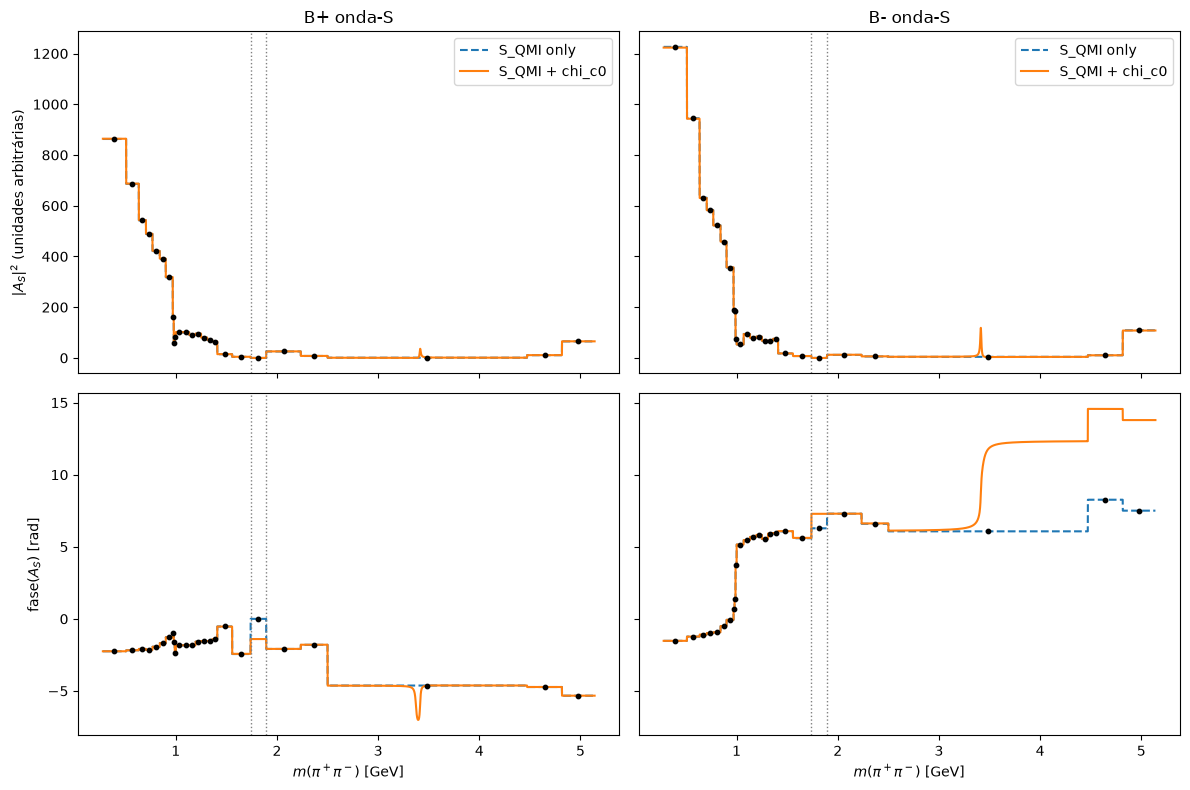

In [66]:
def swave_scan(model, values, mass_scan, *, include_chic0):
    charge = +1 if model is plus_model else -1
    label = "plus" if charge == +1 else "minus"
    real_parts = tuple(p.resolve(values) for p in S_QMI_LINESHAPES[charge].real_parts)
    imaginary_parts = tuple(p.resolve(values) for p in S_QMI_LINESHAPES[charge].imaginary_parts)
    qmi = QMI(knots=QMI_KNOTS_GEV, real_parts=real_parts, imaginary_parts=imaginary_parts,
              interpolation=QMI_INTERPOLATION)
    mag, phase = qmi.interpolated_magnitude_phase(jnp.asarray(mass_scan))
    amplitude = coefficient_at("S_QMI", charge, values) * mag * jnp.exp(1j * phase)
    if include_chic0:
        component = next(c for c in model.amplitude_model.components if c.name == "chi_c0")
        dynamics = component.function
        amplitude = amplitude + (coefficient_at("chi_c0", charge, values)
            * dynamics.lineshape(jnp.asarray(mass_scan), dynamics.context.resolve(values)))
    reference = coefficient_at("rho0_770", charge, values)
    return np.asarray(amplitude * jnp.exp(-1j * jnp.angle(reference)))


swave_mass_scan = np.linspace(QMI_KNOTS_GEV[0], QMI_KNOTS_GEV[-1], 4000)

swave_curves = {}
for charge_label, charge_model in (("B+", plus_model), ("B-", minus_model)):
    for include_chic0, tag in ((False, "S_QMI only"), (True, "S_QMI + chi_c0")):
        swave_curves[(charge_label, tag)] = swave_scan(
            charge_model, values, swave_mass_scan, include_chic0=include_chic0,
        )

qmi_only_knot_values = {
    charge_label: swave_scan(charge_model, values, QMI_BIN_CENTERS, include_chic0=False)
    for charge_label, charge_model in (("B+", plus_model), ("B-", minus_model))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey="row")
for col, charge_label in enumerate(("B+", "B-")):
    for tag, style in (("S_QMI only", "--"), ("S_QMI + chi_c0", "-")):
        amplitude = swave_curves[(charge_label, tag)]
        axes[0, col].plot(swave_mass_scan, np.abs(amplitude) ** 2, style, label=tag)
        axes[1, col].plot(swave_mass_scan, np.unwrap(np.angle(amplitude)), style, label=tag)

    axes[0, col].scatter(
        QMI_BIN_CENTERS, np.abs(qmi_only_knot_values[charge_label]) ** 2,
        s=10, color="black", zorder=3,
    )
    # Unwrap the knot phases and shift each onto the same 2*pi branch as the unwrapped
    # "S_QMI only" curve, so the markers land on the plotted line.
    qmi_only_phase_curve = np.unwrap(np.angle(swave_curves[(charge_label, "S_QMI only")]))
    knot_phase = np.unwrap(np.angle(qmi_only_knot_values[charge_label]))
    curve_at_knots = np.interp(QMI_BIN_CENTERS, swave_mass_scan, qmi_only_phase_curve)
    knot_phase = knot_phase + 2 * np.pi * np.round((curve_at_knots - knot_phase) / (2 * np.pi))
    axes[1, col].scatter(QMI_BIN_CENTERS, knot_phase, s=10, color="black", zorder=3)
    for mass in (D0_VETO_MIN_GEV, D0_VETO_MAX_GEV):
        axes[0, col].axvline(mass, color="grey", ls=":", lw=1)
        axes[1, col].axvline(mass, color="grey", ls=":", lw=1)

    axes[0, col].set_title(f"{charge_label} onda-S")
    axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
    axes[0, col].legend()

axes[0, 0].set_ylabel(r"$|A_S|^2$ (unidades arbitrárias)")
axes[1, 0].set_ylabel(r"fase$(A_S)$ [rad]")
fig.tight_layout()
plt.show()

### QMI ajustado versus tabela 203-112: SWave

Transcrição da imagem fornecida: 25 valores **por intervalo de massa** da Tabela 28,
não 25 nós com um extremo ausente. A referência é desenhada em escadinha: magnitude² e fase constantes dentro
de cada intervalo, com degraus nos limites dos bins. O bin 20 coincide com o veto D0; seus zeros não definem uma
fase física nem são usados como condição de contorno. A comparação exclui `chi_c0`.

Interpretamos o cabeçalho como `|A|² = valor impresso × 10⁻²`, configurável abaixo.
Como a imagem não especifica a normalização das amplitudes da referência,
`COMPARISON_MODE="shape"` compara a forma dividindo cada conjunto pela integral
em massa de `|A_plus|² + |A_minus|²`, fora do veto. É **uma única escala por conjunto**,
preservando a razão entre cargas; isso é apenas uma convenção de visualização,
não a integral física no Dalitz nem uma normalização dos componentes do fit.
`"absolute"` exibe os valores brutos e requer convenções de amplitude compatíveis.

Nossas fases são relativas ao rho. Os offsets explícitos da tabela são zero por
padrão, supondo a mesma referência; a imagem não confirma essa convenção. Não
ajustamos offsets automaticamente. Sem erros/covariâncias na tabela, a comparação
é visual, sem significâncias. Os valores do fit nos centros são avaliações da curva,
não médias de bin nem parâmetros de um novo fit binado.

Nossa onda-S também é mostrada em escadinha, com magnitude² e fase avaliadas
no centro de cada intervalo e mantidas constantes até suas bordas. Isso altera
apenas a visualização; a avaliação constante por bin do fit e a escala visual acima permanecem
as mesmas. O veto D0 fica sem linha nos dois conjuntos.


/var/folders/25/fl6w6s7x2j7b33nf426lhc3m0000gn/T/ipykernel_74126/3600433531.py:125: RuntimeWarning: invalid value encountered in divide
  intensity_pull = (fit_intensity - table_intensity) / np.where(
/var/folders/25/fl6w6s7x2j7b33nf426lhc3m0000gn/T/ipykernel_74126/3600433531.py:128: RuntimeWarning: invalid value encountered in divide
  phase_pull = phase_difference / np.where(phase_difference > 0, phase_error[0], phase_error[1])


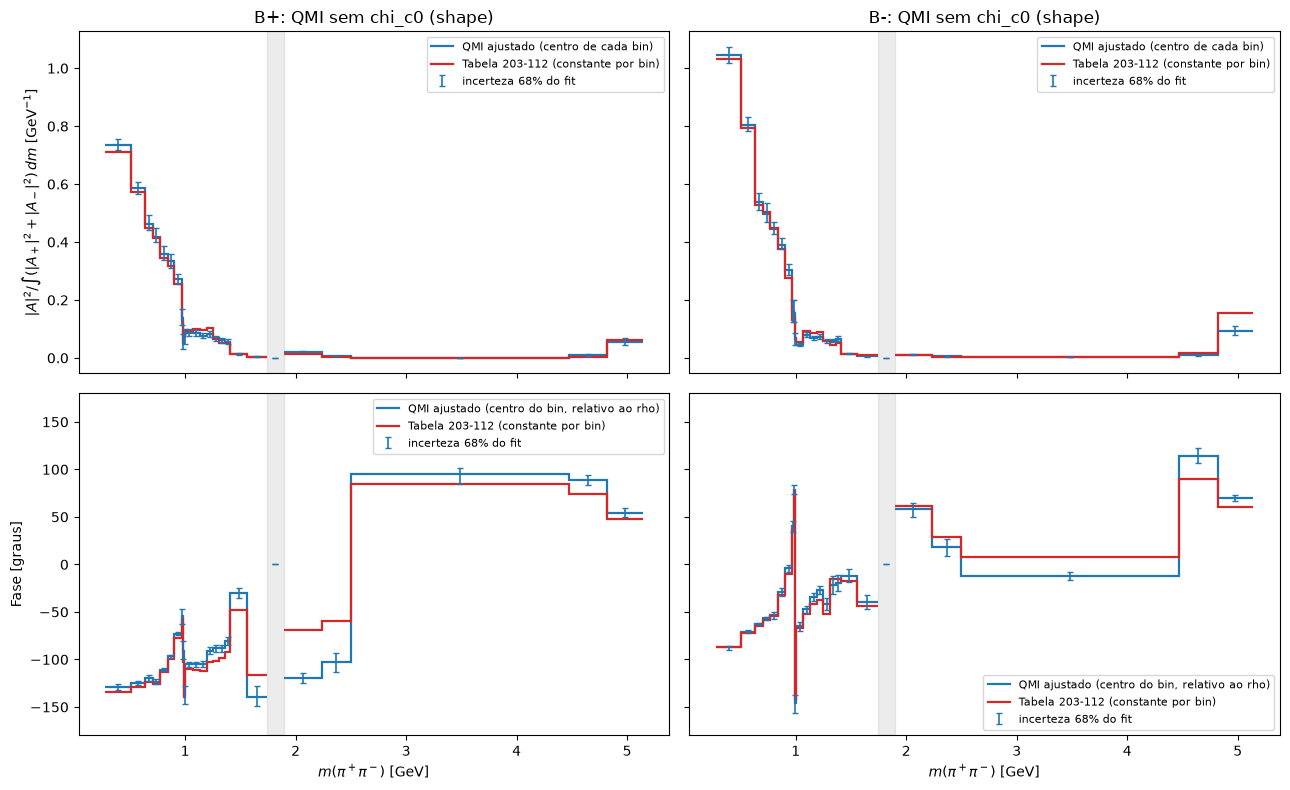

,charge,bin,mass_low_GeV,mass_high_GeV,outside_veto,fit_intensity_at_center,table_intensity,intensity_pull,fit_phase_at_center_deg,table_phase_deg,phase_difference_deg,phase_pull
0,B+,1,0.27914,0.509015,True,0.73604,0.709473,1.39493,-128.821,-133.929,5.10832,1.52301
1,B+,2,0.509015,0.634185,True,0.585165,0.572294,0.724742,-124.907,-129.044,4.13707,2.02282
2,B+,3,0.634185,0.704998,True,0.462559,0.450094,0.598577,-119.599,-124.004,4.40505,1.47226
3,B+,4,0.704998,0.769832,True,0.416771,0.413612,0.183114,-123.411,-125.587,2.17558,0.76698
4,B+,5,0.769832,0.841871,True,0.359326,0.34391,0.689747,-110.763,-113.355,2.59199,1.54915
5,B+,6,0.841871,0.9013,True,0.333123,0.317958,0.699957,-96.1754,-99.602,3.42656,1.85745
6,B+,7,0.9013,0.97,True,0.271158,0.255671,0.94543,-72.9821,-77.058,4.07592,2.2873
7,B+,8,0.97,0.98,True,0.137393,0.12309,0.608353,-54.4707,-56.944,2.47334,0.283417
8,B+,9,0.98,0.99,True,0.0506952,0.0539816,-0.107387,-91.3994,-103.109,11.7096,1.38068
9,B+,10,0.99,1,True,0.070794,0.0734091,-0.0952341,-136.469,-139.79,3.3205,0.327499


In [67]:
# Imagens fornecidas pelo usuário: Tabela 28 + "203-112: SWave".
TABLE_MASS_EDGES_GEV = np.array([
    0.279140, 0.509015, 0.634185, 0.704998, 0.769832, 0.841871,
    0.901300, 0.970000, 0.980000, 0.990000, 1.000000, 1.070000,
    1.133000, 1.195000, 1.250000, 1.310000, 1.360000, 1.410000,
    1.556780, 1.740000, 1.894000, 2.236000, 2.500000, 4.472131,
    4.817487, 5.139690,
])
TABLE_SWAVE = np.array([
    [0.04784, -133.929, 0.06948, -87.310], [0.03859, -129.044, 0.05341, -72.456],
    [0.03035, -124.004, 0.03554, -65.002], [0.02789, -125.587, 0.03390, -58.909],
    [0.02319, -113.355, 0.03016, -54.771], [0.02144, -99.602, 0.02537, -32.422],
    [0.01724, -77.058, 0.01852, -10.049], [0.00830, -56.944, 0.00892, 36.186],
    [0.00364, -103.109, 0.00929, 76.942], [0.00495, -139.790, 0.00463, -141.810],
    [0.00625, -110.510, 0.00365, -66.370], [0.00673, -111.123, 0.00622, -52.224],
    [0.00651, -111.920, 0.00582, -41.931], [0.00688, -102.701, 0.00599, -37.457],
    [0.00434, -101.843, 0.00404, -51.732], [0.00352, -98.925, 0.00307, -15.635],
    [0.00351, -91.702, 0.00351, -15.827], [0.00085, -48.131, 0.00089, -17.899],
    [0.00025, -115.919, 0.00062, -44.178], [0.00000, -0.000, 0.00000, 0.000],
    [0.00082, -68.598, 0.00057, 61.740], [0.00019, -59.636, 0.00029, 28.417],
    [0.00004, 84.743, 0.00020, 8.092], [0.00020, 74.476, 0.00109, 90.238],
    [0.00420, 47.322, 0.01037, 60.449],
])
TABLE_INTENSITY_MULTIPLIER = 1e-2
COMPARISON_MODE = "shape"  # "shape" ou "absolute"
TABLE_PHASE_OFFSET_DEG = {"B+": 0.0, "B-": 0.0}
assert TABLE_SWAVE.shape == (len(TABLE_MASS_EDGES_GEV) - 1, 4)
if COMPARISON_MODE not in ("shape", "absolute"):
    raise ValueError("COMPARISON_MODE deve ser shape ou absolute")

left, right = TABLE_MASS_EDGES_GEV[:-1], TABLE_MASS_EDGES_GEV[1:]
centers, widths = (left + right) / 2, right - left
outside_veto = (right <= D0_VETO_MIN_GEV) | (left >= D0_VETO_MAX_GEV)
reference_intensity = TABLE_SWAVE[:, [0, 2]] * TABLE_INTENSITY_MULTIPLIER

g, gw = np.polynomial.legendre.leggauss(64)
integration_mass = centers[:, None] + widths[:, None] * g / 2
fitted_values_for_comparison = fit_session.result_values(result)
models_for_comparison = (plus_model, minus_model)
fit_integral = 0.0
for model in models_for_comparison:
    amp = swave_scan(model, fitted_values_for_comparison, integration_mass.ravel(), include_chic0=False)
    per_bin = (np.abs(amp.reshape(integration_mass.shape)) ** 2 @ gw) * widths / 2
    fit_integral += per_bin[outside_veto].sum()
table_integral = (reference_intensity.sum(axis=1) * widths)[outside_veto].sum()
fit_scale = fit_integral if COMPARISON_MODE == "shape" else 1.0
table_scale = table_integral if COMPARISON_MODE == "shape" else 1.0
if min(fit_scale, table_scale) <= 0:
    raise ValueError("Escala de comparação deve ser positiva")

wrap_phase = lambda phase: (np.asarray(phase) + 180.0) % 360.0 - 180.0

# Propagação da covariância apenas para barras de erro bin a bin no gráfico.
free_names = [p.name for p in fit_session.parameters if not p.fixed]
covariance = np.asarray(result.covariance, dtype=float)
if covariance.shape != (len(free_names), len(free_names)):
    raise ValueError("A covariância do fit não corresponde aos parâmetros livres")
rng = np.random.default_rng(20260925)
parameter_samples = rng.multivariate_normal(
    [fitted_values_for_comparison[name] for name in free_names], covariance, size=300,
)
parameter_samples = [
    {**fitted_values_for_comparison, **dict(zip(free_names, sample))}
    for sample in parameter_samples
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")
comparison_rows = []
for col, (label, model) in enumerate(zip(("B+", "B-"), models_for_comparison)):
    midpoint_amp = swave_scan(model, fitted_values_for_comparison, centers, include_chic0=False)
    sampled_amp = np.asarray([
        swave_scan(model, sample, centers, include_chic0=False)
        for sample in parameter_samples
    ])
    fit_intensity = np.abs(midpoint_amp) ** 2 / fit_scale
    sampled_intensity = np.abs(sampled_amp) ** 2 / fit_scale
    intensity_low, intensity_high = np.nanpercentile(sampled_intensity, (16, 84), axis=0)
    intensity_error = np.vstack((fit_intensity - intensity_low, intensity_high - fit_intensity))

    fit_phase = wrap_phase(np.degrees(np.angle(midpoint_amp)))
    sampled_phase = np.degrees(np.angle(sampled_amp))
    phase_delta = wrap_phase(sampled_phase - fit_phase[None, :])
    phase_low, phase_high = np.nanpercentile(phase_delta, (16, 84), axis=0)
    phase_error = np.vstack((-phase_low, phase_high))

    axes[0, col].errorbar(
        centers, fit_intensity, yerr=intensity_error, fmt="none",
        ecolor="tab:blue", elinewidth=1.2, capsize=2, label="incerteza 68% do fit",
    )
    axes[0, col].stairs(
        np.where(outside_veto, fit_intensity, np.nan), TABLE_MASS_EDGES_GEV,
        baseline=None, color="tab:blue", linewidth=1.6,
        label="QMI ajustado (centro de cada bin)",
    )
    axes[0, col].stairs(
        np.where(outside_veto, reference_intensity[:, col] / table_scale, np.nan),
        TABLE_MASS_EDGES_GEV, baseline=None, color="tab:red", linewidth=1.6,
        label="Tabela 203-112 (constante por bin)",
    )
    axes[1, col].errorbar(
        centers, fit_phase, yerr=phase_error, fmt="none",
        ecolor="tab:blue", elinewidth=1.2, capsize=2, label="incerteza 68% do fit",
    )
    axes[1, col].stairs(
        np.where(outside_veto & (np.abs(midpoint_amp) > 0), fit_phase, np.nan),
        TABLE_MASS_EDGES_GEV, baseline=None, color="tab:blue", linewidth=1.6,
        label="QMI ajustado (centro do bin, relativo ao rho)",
    )
    valid_phase = outside_veto & (reference_intensity[:, col] > 0)
    table_phase = wrap_phase(TABLE_SWAVE[:, 2 * col + 1] + TABLE_PHASE_OFFSET_DEG[label])
    axes[1, col].stairs(
        np.where(valid_phase, table_phase, np.nan), TABLE_MASS_EDGES_GEV,
        baseline=None, color="tab:red", linewidth=1.6,
        label="Tabela 203-112 (constante por bin)",
    )
    axes[0, col].set_title(f"{label}: QMI sem chi_c0 ({COMPARISON_MODE})")
    axes[1, col].set_ylim(-180, 180)
    axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
    for ax in axes[:, col]:
        ax.axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, color="grey", alpha=0.15)
        ax.legend(fontsize=8)
    # Pull (fit - tabela) / erro do fit: a tabela não tem erros, então só a incerteza 68%
    # do fit entra; das barras assimétricas usa-se o lado voltado para a referência.
    table_intensity = reference_intensity[:, col] / table_scale
    intensity_pull = (fit_intensity - table_intensity) / np.where(
        fit_intensity > table_intensity, intensity_error[0], intensity_error[1])
    phase_difference = wrap_phase(fit_phase - table_phase)
    phase_pull = phase_difference / np.where(phase_difference > 0, phase_error[0], phase_error[1])
    for k in range(len(centers)):
        comparison_rows.append({
            "charge": label, "bin": k + 1, "mass_low_GeV": left[k], "mass_high_GeV": right[k],
            "outside_veto": bool(outside_veto[k]),
            "fit_intensity_at_center": fit_intensity[k],
            "table_intensity": table_intensity[k],
            "intensity_pull": intensity_pull[k] if outside_veto[k] else np.nan,
            "fit_phase_at_center_deg": fit_phase[k],
            "table_phase_deg": table_phase[k] if valid_phase[k] else np.nan,
            "phase_difference_deg": phase_difference[k] if valid_phase[k] else np.nan,
            "phase_pull": phase_pull[k] if valid_phase[k] else np.nan,
        })
axes[0, 0].set_ylabel(r"$|A|^2 / \int (|A_+|^2+|A_-|^2)\,dm$ [GeV$^{-1}$]"
                       if COMPARISON_MODE == "shape" else r"$|A|^2$ (escala bruta)")
axes[1, 0].set_ylabel("Fase [graus]")
fig.tight_layout()
plt.show()
swave_table_comparison = pd.DataFrame(comparison_rows)
display(swave_table_comparison)

In [68]:
comparison_figure = axes[0, 0].figure
comparison_axes = axes

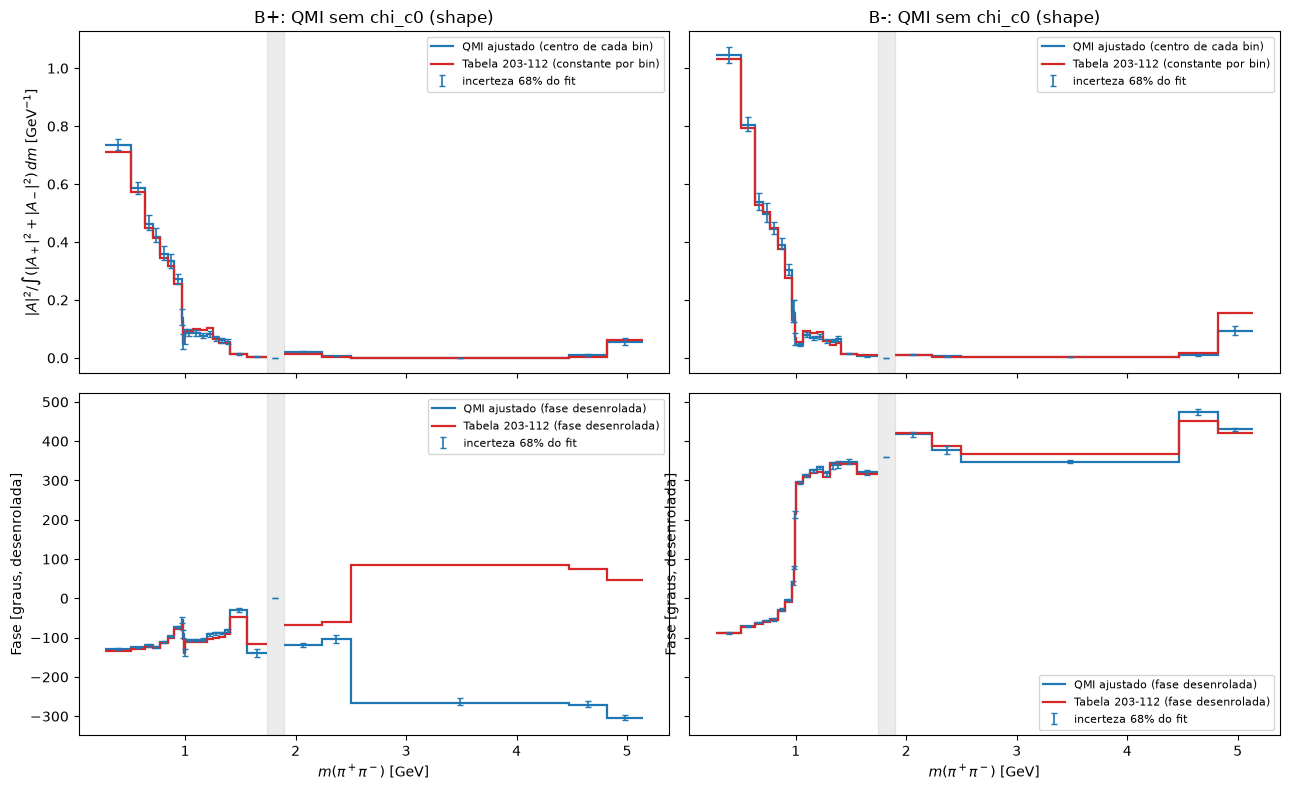

In [69]:
# Redesenha apenas os painéis de fase com fases desenroladas, como no plot de start.
for col, (label, model) in enumerate(zip(("B+", "B-"), models_for_comparison)):
    ax = comparison_axes[1, col]
    ax.clear()

    midpoint_amp = swave_scan(model, fitted_values_for_comparison, centers, include_chic0=False)
    sampled_amp = np.asarray([
        swave_scan(model, sample, centers, include_chic0=False)
        for sample in parameter_samples
    ])
    fit_phase_unwrapped = np.degrees(np.unwrap(np.angle(midpoint_amp)))
    sampled_phase_unwrapped = np.degrees(np.unwrap(np.angle(sampled_amp), axis=1))
    phase_delta = sampled_phase_unwrapped - fit_phase_unwrapped[None, :]
    phase_low, phase_high = np.nanpercentile(phase_delta, (16, 84), axis=0)
    phase_error = np.vstack((-phase_low, phase_high))

    ax.errorbar(
        centers, fit_phase_unwrapped, yerr=phase_error, fmt="none",
        ecolor="tab:blue", elinewidth=1.2, capsize=2, label="incerteza 68% do fit",
    )
    ax.stairs(
        np.where(outside_veto, fit_phase_unwrapped, np.nan), TABLE_MASS_EDGES_GEV,
        baseline=None, color="tab:blue", linewidth=1.6,
        label="QMI ajustado (fase desenrolada)",
    )

    table_phase_unwrapped = np.degrees(np.unwrap(np.radians(
        wrap_phase(TABLE_SWAVE[:, 2 * col + 1] + TABLE_PHASE_OFFSET_DEG[label])
    )))
    valid_phase = outside_veto & (reference_intensity[:, col] > 0)
    ax.stairs(
        np.where(valid_phase, table_phase_unwrapped, np.nan), TABLE_MASS_EDGES_GEV,
        baseline=None, color="tab:red", linewidth=1.6,
        label="Tabela 203-112 (fase desenrolada)",
    )
    ax.axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, color="grey", alpha=0.15)
    ax.set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
    ax.set_ylabel("Fase [graus, desenrolada]")
    ax.legend(fontsize=8)

from IPython.display import display
display(comparison_figure)

### Onda-S antes do veto D0

Mesma comparação acima (QMI sem `chi_c0` vs. Tabela 203-112), restrita aos bins com
`m(pi+pi-) < D0_VETO_MIN_GEV`, onde está quase toda a estrutura da onda-S e que fica comprimida
no eixo completo até 5.1 GeV. A escala `shape` é a mesma da figura completa (integral fora do veto
em todo o intervalo), não renormalizada só nesta região. Fases desenroladas a partir do primeiro bin.


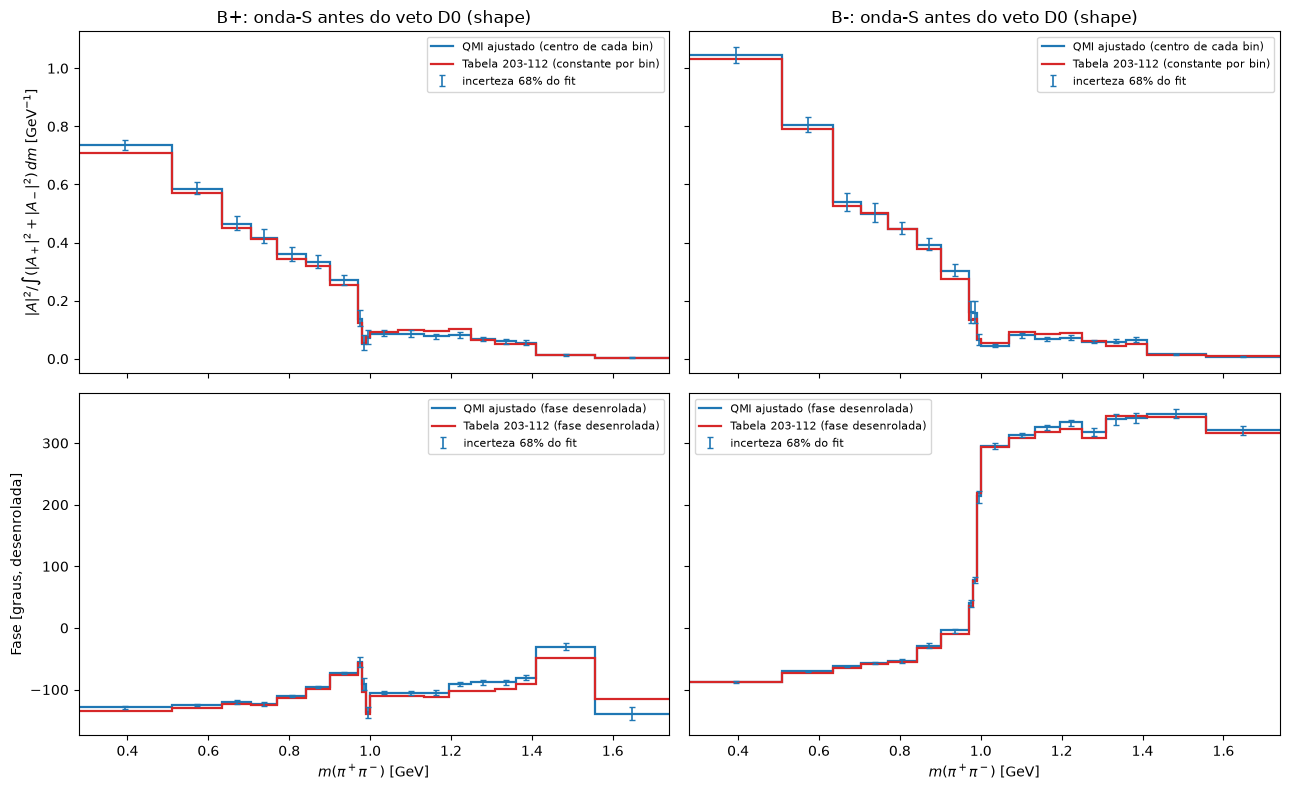

In [70]:
def plot_swave_region(region, region_title):
    """Comparação QMI vs. Tabela 203-112 restrita a um bloco contíguo de bins."""
    bins = np.flatnonzero(region)
    assert np.all(np.diff(bins) == 1), "a região deve ser um bloco contíguo de bins"
    region_edges = TABLE_MASS_EDGES_GEV[bins[0]: bins[-1] + 2]
    region_centers = centers[region]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")
    for col, (label, model) in enumerate(zip(("B+", "B-"), models_for_comparison)):
        midpoint_amp = swave_scan(model, fitted_values_for_comparison, region_centers, include_chic0=False)
        sampled_amp = np.asarray([
            swave_scan(model, sample, region_centers, include_chic0=False)
            for sample in parameter_samples
        ])

        fit_intensity = np.abs(midpoint_amp) ** 2 / fit_scale
        intensity_low, intensity_high = np.nanpercentile(np.abs(sampled_amp) ** 2 / fit_scale, (16, 84), axis=0)
        axes[0, col].errorbar(
            region_centers, fit_intensity,
            yerr=np.vstack((fit_intensity - intensity_low, intensity_high - fit_intensity)), fmt="none",
            ecolor="tab:blue", elinewidth=1.2, capsize=2, label="incerteza 68% do fit",
        )
        axes[0, col].stairs(fit_intensity, region_edges, baseline=None, color="tab:blue",
                            linewidth=1.6, label="QMI ajustado (centro de cada bin)")
        axes[0, col].stairs(reference_intensity[region, col] / table_scale, region_edges,
                            baseline=None, color="tab:red", linewidth=1.6,
                            label="Tabela 203-112 (constante por bin)")

        fit_phase = np.degrees(np.unwrap(np.angle(midpoint_amp)))
        phase_delta = np.degrees(np.unwrap(np.angle(sampled_amp), axis=1)) - fit_phase[None, :]
        phase_low, phase_high = np.nanpercentile(phase_delta, (16, 84), axis=0)
        axes[1, col].errorbar(
            region_centers, fit_phase, yerr=np.vstack((-phase_low, phase_high)), fmt="none",
            ecolor="tab:blue", elinewidth=1.2, capsize=2, label="incerteza 68% do fit",
        )
        axes[1, col].stairs(fit_phase, region_edges, baseline=None, color="tab:blue",
                            linewidth=1.6, label="QMI ajustado (fase desenrolada)")
        table_phase = np.degrees(np.unwrap(np.radians(
            TABLE_SWAVE[region, 2 * col + 1] + TABLE_PHASE_OFFSET_DEG[label]
        )))
        valid_phase = reference_intensity[region, col] > 0
        axes[1, col].stairs(np.where(valid_phase, table_phase, np.nan), region_edges,
                            baseline=None, color="tab:red", linewidth=1.6,
                            label="Tabela 203-112 (fase desenrolada)")

        axes[0, col].set_title(f"{label}: {region_title} ({COMPARISON_MODE})")
        axes[1, col].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
        axes[1, col].set_xlim(region_edges[0], region_edges[-1])
        for ax in axes[:, col]:
            ax.legend(fontsize=8)
    axes[0, 0].set_ylabel(r"$|A|^2 / \int (|A_+|^2+|A_-|^2)\,dm$ [GeV$^{-1}$]"
                          if COMPARISON_MODE == "shape" else r"$|A|^2$ (escala bruta)")
    axes[1, 0].set_ylabel("Fase [graus, desenrolada]")
    fig.tight_layout()
    plt.show()


plot_swave_region(right <= D0_VETO_MIN_GEV, "onda-S antes do veto D0")


### Onda-S depois do veto D0

Mesma comparação, restrita aos bins com `m(pi+pi-) > D0_VETO_MAX_GEV` (até ~5.14 GeV, região do
`chi_c0`, que continua excluído da curva). Mesma escala `shape` da figura completa. A fase é desenrolada
a partir do primeiro bin após o veto: não há continuidade definida através do veto, então o offset
de 2π entre as duas regiões não tem significado.


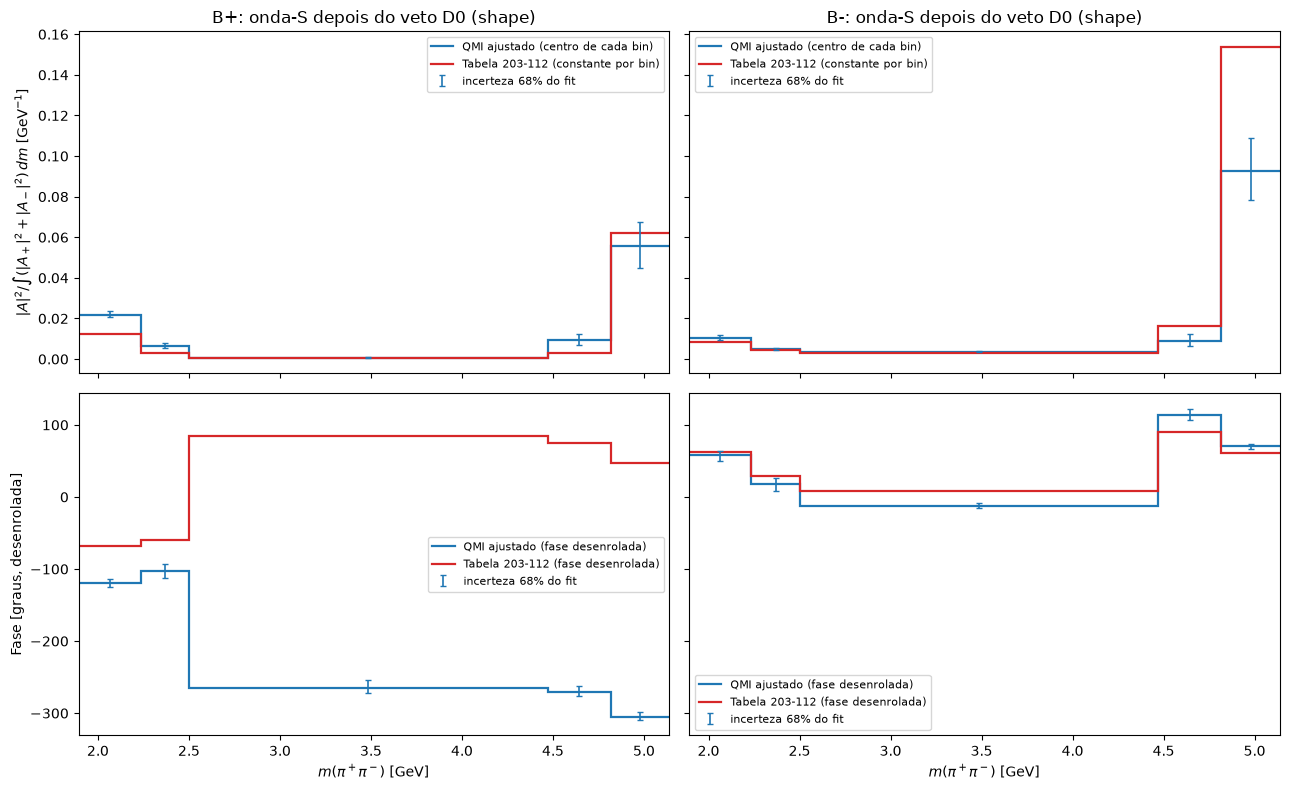

In [71]:
plot_swave_region(left >= D0_VETO_MAX_GEV, "onda-S depois do veto D0")


## Projeções pós-ajuste

`s13` (canal `pi± pi∓`), um painel por carga, com componente de background e curva total.

## Projeções dobradas (folded)

`s13` e `s23` são exatamente o par trocado pela simetrização das duas `pi+`/`pi-` idênticas
(`(0,2)` <-> `(1,2)` sob a troca `0<->1`), então `s_low=min(s13,s23)` e `s_high=max(s13,s23)`
são as duas projeções fisicamente distintas (não duas visões da mesma) recomendadas em
`docs/backgrounds_and_vetoes.md` para um par de partículas idênticas -- cada uma dobra os dados e
a projeção do ajuste dentro do painel de cada carga (B+ e B- nunca são misturados).

array([[<Axes: ylabel='Candidates / 0.231 GeV$^2$'>,
        <Axes: ylabel='Candidates / 0.231 GeV$^2$'>],
       [<Axes: xlabel='$s_{\\mathrm{low}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>,
        <Axes: xlabel='$s_{\\mathrm{low}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>]],
      dtype=object)

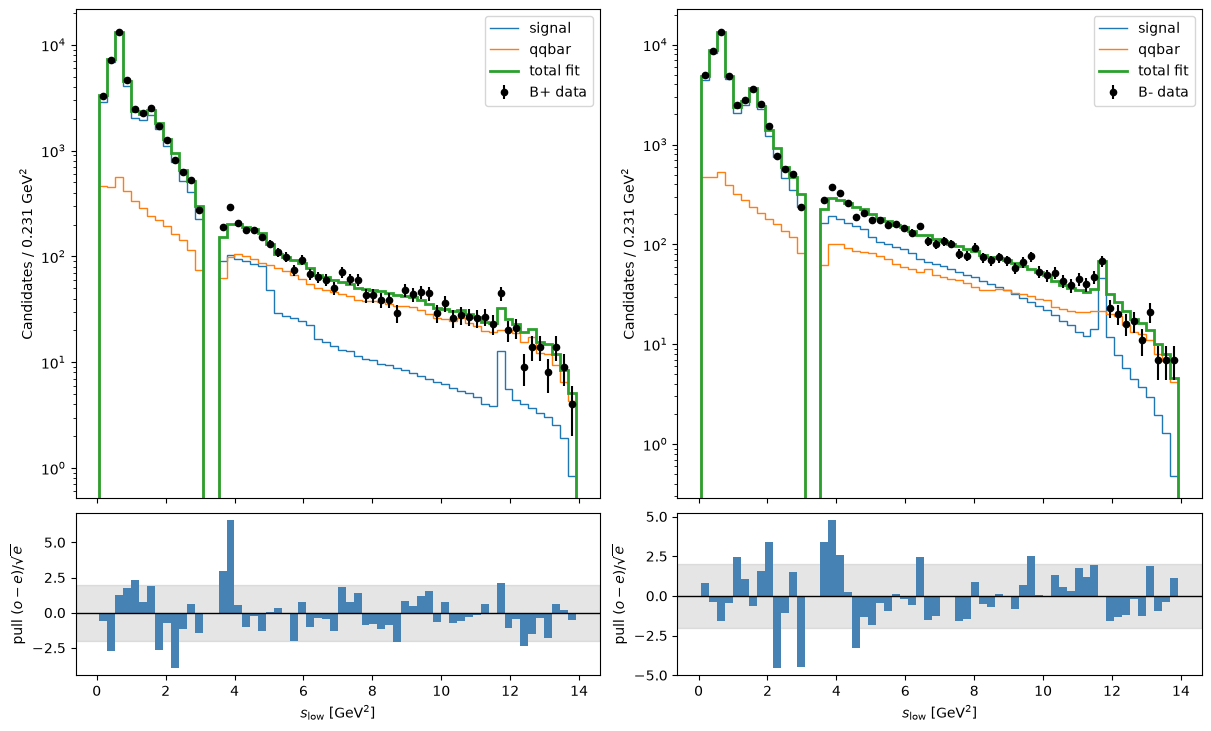

In [72]:
fit_session.plot_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="low",
    bins=60, show_components=True, show_pulls=True, projection_size=2_000_000, log_scale=True
)


array([[<Axes: ylabel='Candidates / 0.256 GeV$^2$'>,
        <Axes: ylabel='Candidates / 0.256 GeV$^2$'>],
       [<Axes: xlabel='$s_{\\mathrm{high}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>,
        <Axes: xlabel='$s_{\\mathrm{high}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>]],
      dtype=object)

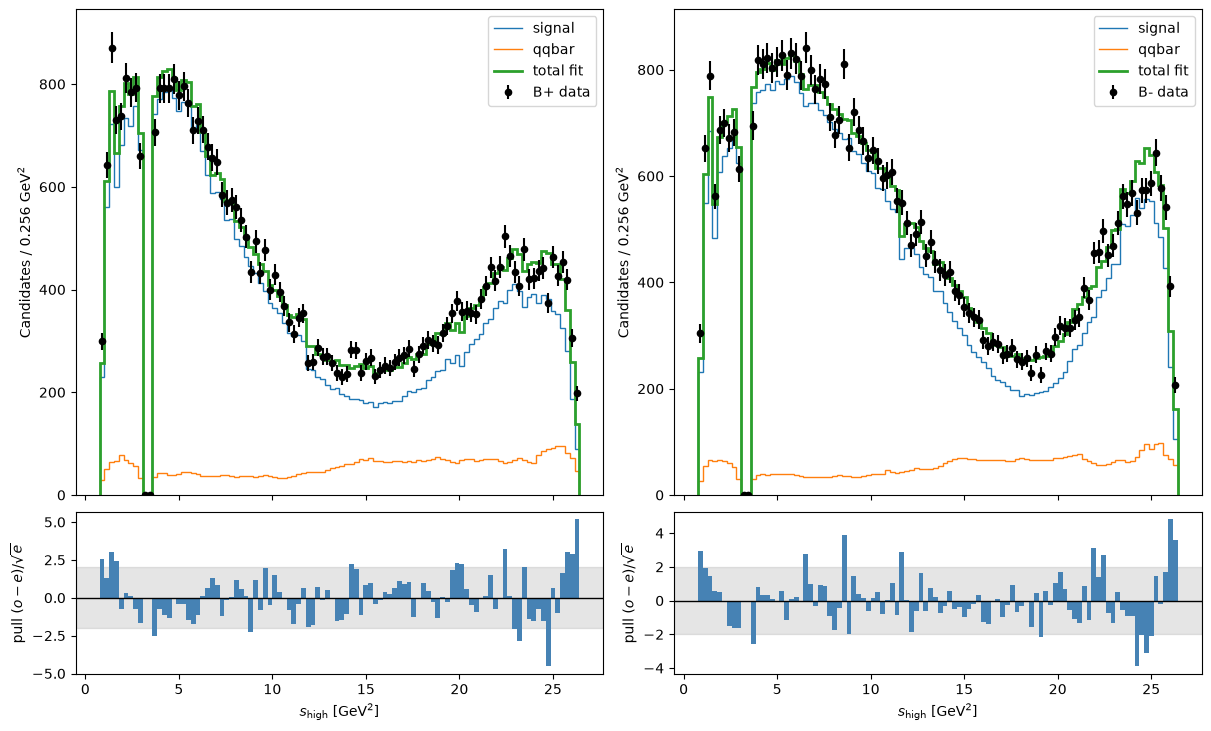

In [73]:
fit_session.plot_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="high",
    bins=100, show_components=True, show_pulls=True, projection_size=2_000_000
)


## Goodness-of-fit

Chi2 binado de Pearson no plano Square-Dalitz dobrado `(m', theta')` (mesmo par/convenção
`SQDP_PAIR`/`folded=True` usado para ACC e background acima), por carga -- ver
`docs/goodness_of_fit.md` para a leitura de `dof_min`/`dof_max`/`p_value_min`/`p_value_max`: como
os parâmetros vêm de um ajuste de máxima verossimilhança não-binado, o número exato de graus de
liberdade não é conhecido, e o resultado reporta as duas cotas de Williams (Sec. 3.1) em vez de um
único par dof/p-value potencialmente errado.

In [74]:
gof_square_dalitz = fit_session.goodness_of_fit_chi2(
    result, square_dalitz=True, folded=True,
    mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR,
    bins=25, projection_size=1_000_000
)
for charge, res in gof_square_dalitz.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  "
          f"p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")


plus: chi2=1028.2  n_bins=625  n_free_parameters=117
       dof in [507, 624]  p-value in [1.132e-37, 2.759e-22]
minus: chi2=1004.7  n_bins=625  n_free_parameters=117
       dof in [507, 624]  p-value in [4.279e-35, 2.732e-20]


### Resíduos no Dalitz convencional dobrado

Dados e expectativas são dobrados em `(min(s13,s23), max(s13,s23))`, como o ROOT atual.

In [75]:
gof_dp = fit_session.goodness_of_fit_chi2(result, x="s13", y="s23", folded=True, bins=25, projection_size=1_000_000)
for charge, res in gof_dp.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")

plus: chi2=729.1  n_bins=368  n_free_parameters=117
       dof in [250, 367]  p-value in [2.166e-48, 3.505e-26]
minus: chi2=707.7  n_bins=367  n_free_parameters=117
       dof in [249, 366]  p-value in [1.463e-45, 5.072e-24]


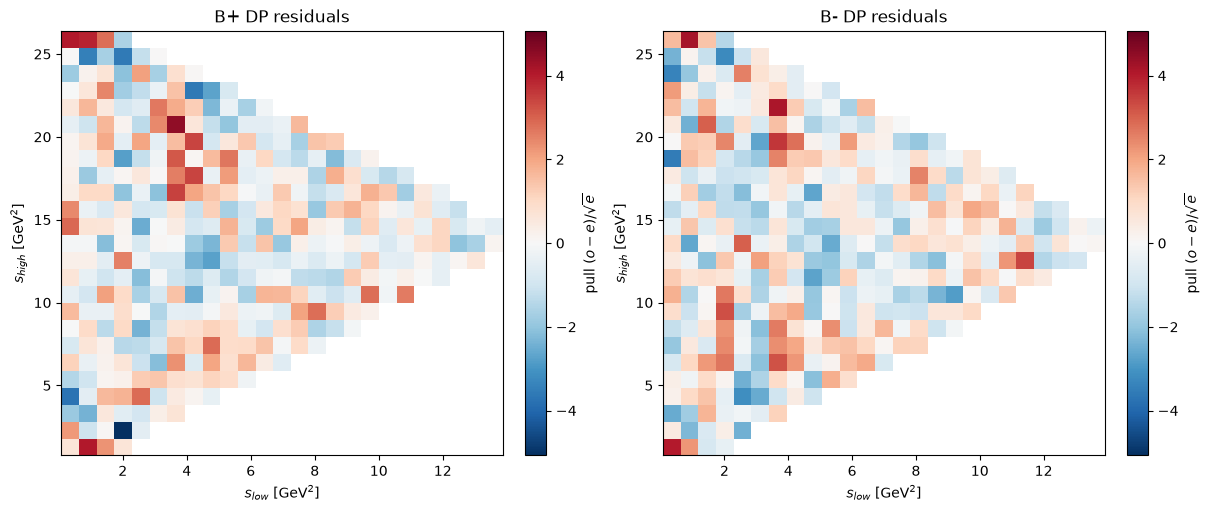

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pull_max = max(np.nanmax(np.abs(res.pulls)) for res in gof_dp.values())
for ax, (charge, res) in zip(axes, gof_dp.items()):
    x_edges, y_edges = res.edges
    mesh = ax.pcolormesh(x_edges, y_edges, res.pulls.T, cmap="RdBu_r", vmin=-pull_max, vmax=pull_max, shading="flat")
    ax.set_xlabel(r"$s_{low}$ [GeV$^2$]")
    ax.set_ylabel(r"$s_{high}$ [GeV$^2$]")
    ax.set_title(f"B{'+' if charge == 'plus' else '-'} DP residuals")
    fig.colorbar(mesh, ax=ax, label=r"pull $(o-e)/\sqrt{e}$")

### Mapa de resíduos no Dalitz Plot (Square-Dalitz)

`(observado - esperado) / sqrt(esperado)` por bin `(m', theta')`, mesma grade usada no chi2 acima
(`res.pulls`/`res.edges` de `BinnedChi2Result`). Bins sem eventos esperados (`expected <= 0`)
aparecem em branco (`nan`, excluídos do chi2). Um painel por carga, escala de cor divergente
centrada em zero.

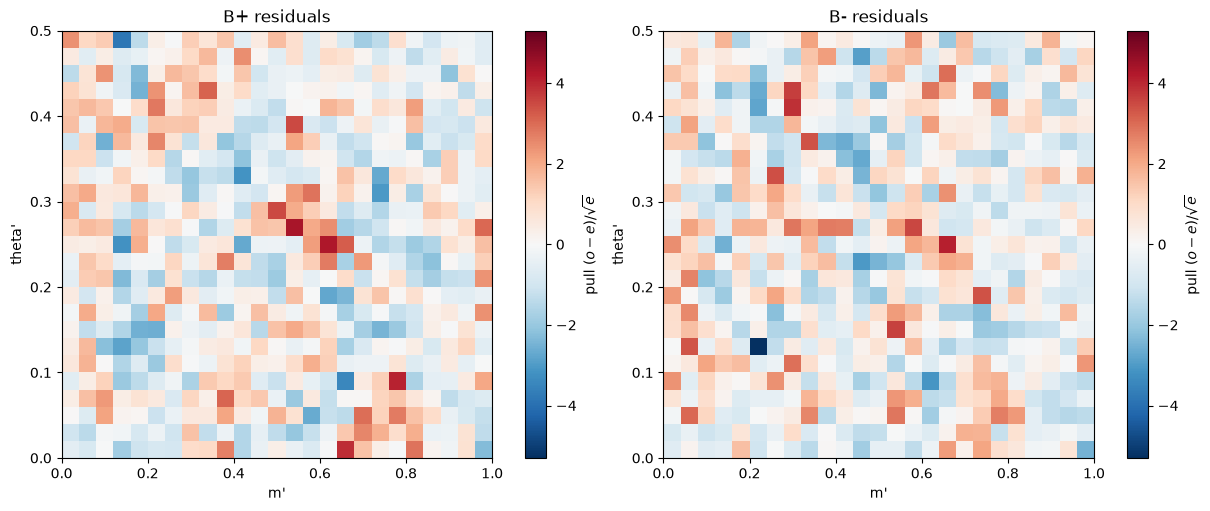

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pull_max = max(
    np.nanmax(np.abs(res.pulls)) for res in gof_square_dalitz.values()
)
for ax, (charge, res) in zip(axes, gof_square_dalitz.items()):
    mp_edges, tp_edges = res.edges
    mesh = ax.pcolormesh(
        mp_edges, tp_edges, res.pulls.T,
        cmap="RdBu_r", vmin=-pull_max, vmax=pull_max, shading="flat",
    )
    ax.set_xlabel("m'")
    ax.set_ylabel("theta'")
    ax.set_title(f"B{'+' if charge == 'plus' else '-'} residuals")
    fig.colorbar(mesh, ax=ax, label=r"pull $(o-e)/\sqrt{e}$")


Chi2 binado 1D na projeção dobrada `s_low` (mesma convenção da seção anterior), por carga.

In [78]:
gof_s_low = fit_session.goodness_of_fit_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="low", bins=60,
)
for charge, res in gof_s_low.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  "
          f"p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")


plus: chi2=141.2  n_bins=58  n_free_parameters=117
       dof in [-60, 57]  p-value in [nan, 4.252e-09]
minus: chi2=188.3  n_bins=58  n_free_parameters=117
       dof in [-60, 57]  p-value in [nan, 6.031e-16]


## Limites da comparação

A configuração usa CP por nó, sem normalização individual de nenhum componente e com
massas/larguras fixas, inclusive rho/f2, conforme solicitado. Os yields e a seleção permanecem os do ROOT local, e a proveniência dos
CSVs continua pendente. A interpolação configurada em s é uma escolha explícita, não uma equivalência
certificada com os bins do draft. Confirmar a origem dos inputs antes de reproduzir 212-112.

Após executar: inspecionar EDM/covariância, repetir inicializações e verificar estabilidade
de normalização. `valid=True` não garante um bom ajuste aos dados. NLLs absolutos não
são comparáveis sem igualar medida, domínio, constantes e seleção. Ao variar a quadratura,
reconstruir os modelos e a sessão, inclusive as normalizações de backgrounds.

### Resíduos adaptativos com KD-tree

In [79]:
# Resíduos locais adaptativos por k-vizinhos (KD-tree)
from dalitzplotfitter.kinematics import invariants_to_square_dalitz, fold_thetaprime

def _kdtree_points(charge, square=False, k=50, size=120_000):
    data = fit_session.plus_data if charge == "plus" else fit_session.minus_data
    sample = fit_session.plus_model.generate_phase_space(size, seed=20260911 if charge == "plus" else 20260912)
    other = fit_session.minus_model.generate_phase_space(size, seed=20260913 if charge == "plus" else 20260914)
    comps = fit_session._projection_components_pair(fit_session.result_values(result), sample, other)[0 if charge == "plus" else 1]
    exp_points, exp_weights = [], []
    for _, s, w in comps:
        d = s.as_dict()
        if square:
            a, b = invariants_to_square_dalitz(d["s12"], d["s13"], d["s23"], mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR)
            b = fold_thetaprime(b)
        else:
            a, b = jnp.minimum(d["s13"], d["s23"]), jnp.maximum(d["s13"], d["s23"])
        exp_points.append(np.column_stack((np.asarray(a), np.asarray(b))))
        exp_weights.append(np.asarray(w))
    d = data.as_dict()
    if square:
        a, b = invariants_to_square_dalitz(d["s12"], d["s13"], d["s23"], mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR)
        b = fold_thetaprime(b)
    else:
        a, b = jnp.minimum(d["s13"], d["s23"]), jnp.maximum(d["s13"], d["s23"])
    return kdtree_local_residuals(np.column_stack((np.asarray(a), np.asarray(b))), np.concatenate(exp_points), np.concatenate(exp_weights), k=k)

kdtree_residuals = {}
for coordinate in ("dp", "square"):
    for charge in ("plus", "minus"):
        pulls, observed_count, expected_count, radii = _kdtree_points(charge, square=coordinate == "square")
        kdtree_residuals[(coordinate, charge)] = pulls
        print(coordinate, charge, "median pull=", float(np.median(pulls)), "RMS=", float(np.std(pulls)))

dp plus median pull= 0.2625371090712762 RMS= 1.8154702753331056
dp minus median pull= 0.23403878370307074 RMS= 1.7301635989285555
square plus median pull= 0.24614073242371445 RMS= 1.8454504761744788
square minus median pull= 0.22857355991902503 RMS= 1.7399146124777172


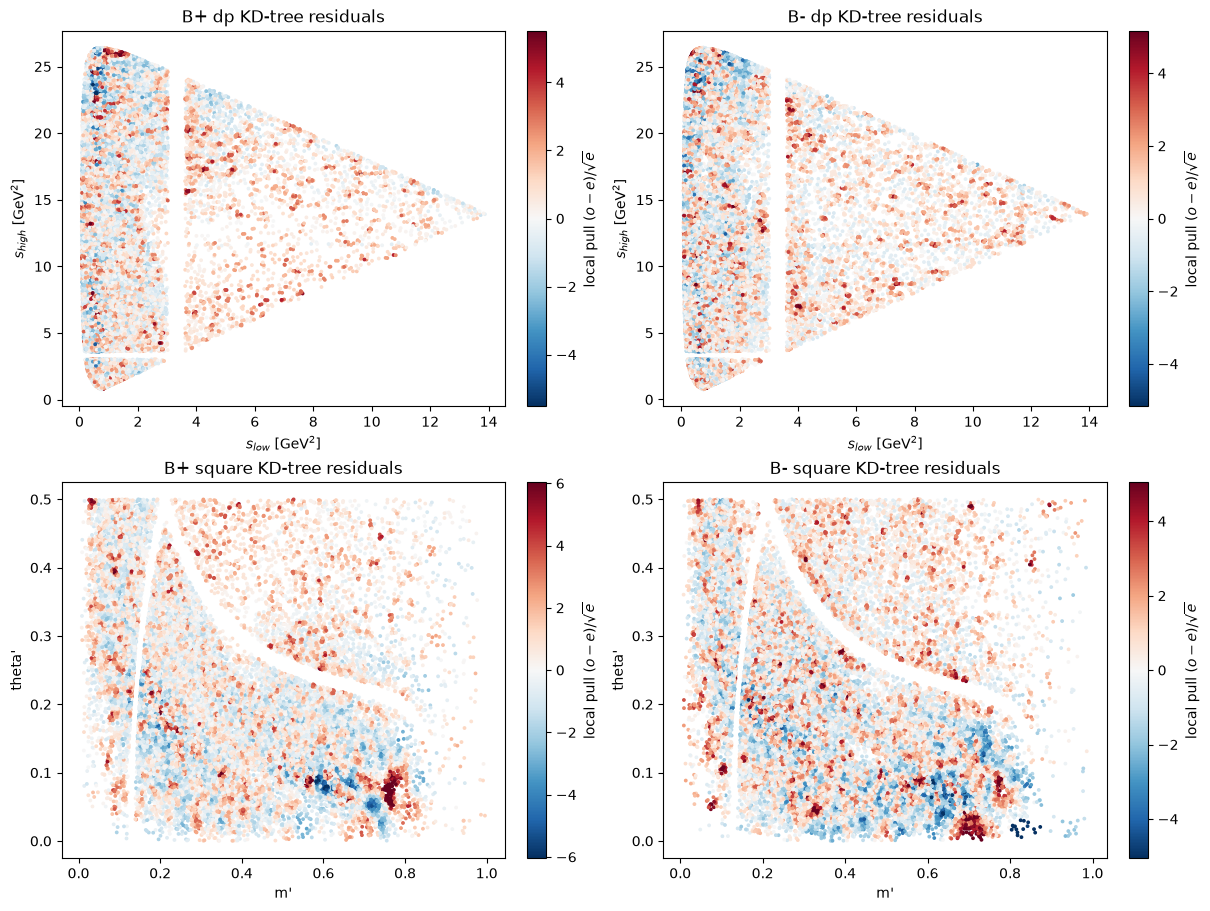

In [80]:
# KD-tree pull map: cada ponto observado recebe o pull da vizinhança local.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for row, coordinate in enumerate(("dp", "square")):
    for col, charge in enumerate(("plus", "minus")):
        data = fit_session.plus_data if charge == "plus" else fit_session.minus_data
        d = data.as_dict()
        if coordinate == "square":
            xx, yy = invariants_to_square_dalitz(d["s12"], d["s13"], d["s23"], mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR)
            yy = fold_thetaprime(yy)
            xlabel, ylabel = "m'", "theta'"
        else:
            xx, yy = jnp.minimum(d["s13"], d["s23"]), jnp.maximum(d["s13"], d["s23"])
            xlabel, ylabel = r"$s_{low}$ [GeV$^2$]", r"$s_{high}$ [GeV$^2$]"
        pulls = kdtree_residuals[(coordinate, charge)]
        scale = max(float(np.nanpercentile(np.abs(pulls), 99)), 1.0)
        mesh = axes[row, col].scatter(np.asarray(xx), np.asarray(yy), c=pulls, s=3, cmap="RdBu_r", vmin=-scale, vmax=scale, rasterized=True)
        axes[row, col].set(xlabel=xlabel, ylabel=ylabel, title=f"B{'+' if charge == 'plus' else '-'} {coordinate} KD-tree residuals")
        fig.colorbar(mesh, ax=axes[row, col], label=r"local pull $(o-e)/\sqrt{e}$")